# Fisher-vs-MCMC cross-check: PFS $P_\ell + B_0$ + DESI DR2 BAO + BBN+$n_s$ ($\nu\Lambda$CDM)

> **This notebook was REPLACED wholesale from the LCDM production notebook**
> (`mcmc_joint_PFS_BAO_BBN_ns_LCDM.ipynb`), adapted to $\nu\Lambda$CDM. The previous file at
> this path was a pre-marginalization fossil (`run_nuts` on the full space, `eft_eq12` spec);
> it was discarded, not migrated.

RWMH posterior on the **same forecast likelihood** as `fisher_joint_PFS_BAO_BBN_ns_nuLCDM.ipynb`,
to test whether the Fisher (Gaussian) forecast is consistent with the full posterior. The exact
likelihood is the ground-truth definition and the smoke gate; production samples a Taylor surrogate
of it (see "Production sampling" below).

**Setup (matches the nuLCDM Fisher notebook exactly):**
- PFS full-shape $P_\ell(k) + B_0$ (7 bins, AP), DESI DR2 BAO, BBN + $n_{s,10}$ + EFT/stochastic priors.
- **nuLCDM cosmology basis**: the LCDM core $(\omega_b, \omega_c, \log A, n_s, h)$ **plus $m_\nu$** —
  6 sampled cosmology parameters ($n_{\rm NL}$ 26 → 27). $m_\nu$ is placed LAST in the packed cosmology
  so the fixed-cosmo indices $[5,6,7,8]$ ($z, A_b, \eta_b, \log T_{\rm AGN}$) are unchanged from LCDM.
- **Noiseless mock**: the "data" is the fiducial theory vector ($m_\nu = 0.06$ eV), so the posterior is
  centred at the fiducial and its width/shape directly test the Fisher approximation.
- **Sample the full varied block** (cosmology incl. $m_\nu$ + per-bin EFT/survey params, minus the fixed
  ones) — the same block the Fisher marginalises — then compare the marginal cosmology posterior to the
  Fisher cosmology block.
- **EFT/stochastic priors: the DESI DR1-reanalysis spec, b1σ8 variant** (`desi_dr1_reanalysis_2511_20757_b1s8`,
  arXiv:2511.20757 Table I) loaded under `phase="nulcdm"`. The b1 row carries `measure: b1sigma8`, so
  $b_1\sigma_8(z) \sim \mathcal{U}[0,3]$ is the sampled coordinate — the Table-I measure the phase gate
  protects (in nuLCDM the dropped raw-b1 prior weight would otherwise land on $\Sigma m_\nu$; see
  theory.md: The b1-sigma8 measure). **The same spec drives the comparison Fisher**, so the sampled target and the
  red ellipses below are the same statistical model (one documented asymmetry: the diagonal-only Fisher
  machinery consumes the *marginal* widths of the correlated counterterm block).
- **$m_\nu$ prior**: flat with the physical bound $\Sigma m_\nu \ge 0$, applied as a $-\infty$ indicator in
  the sampled-block prior (RWMH-safe; NUTS-hostile — one reason production samples with RWMH, not NUTS).
- **Whitening** uses the legacy-spec prior-included Fisher purely as the **sampling geometry**
  (an affine reparametrisation of the MH proposal). It enters neither the target nor the comparison Fisher.

> **Runtime and committed state.** This notebook is committed with **`SMOKE_TEST=False`** — the stored
> outputs below are the **production RWMH-on-surrogate run** (200k draws/chain, 20k burn, 4 chains,
> seed 20260806; R-hat $\le 1.0006$, acceptance $\approx 0.28$; ~30 min wall). Production RWMH on the
> Taylor surrogate is dense algebra with no theory evaluation per step, so it takes **minutes** rather
> than the days the exact per-bin path would need for the same chain. Setting `SMOKE_TEST=True` instead
> runs the EXACT per-bin path (a tiny gradient-free RWMH gate on the ground-truth posterior plus a
> seconds-scale surrogate shakedown); its first exact-path evaluation compiles the 27-dim nuLCDM marginal
> posterior (~1 min with a warm XLA cache). Independent convergence + b1σ8-measure/$m_\nu$ validation also
> lives in the separate nuLCDM gate task (`scripts/desi_prior_validation.py --cosmology nulcdm`).

In [1]:
from functools import partial
import os
import time

N_THREADS = os.cpu_count() or 1
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = str(N_THREADS)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-jaxptpolypol")

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
plt.rcParams.update({
    "text.usetex": True, "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern", "font.size": 22})

import numpy as np
from tqdm.auto import tqdm

import jax
jax.config.update("jax_enable_x64", True)

# Persistent XLA compilation cache: repeated notebook runs reuse compiled graphs
import pathlib as _pathlib
jax.config.update("jax_compilation_cache_dir", str(_pathlib.Path.home() / ".jax_xla_cache"))
jax.config.update("jax_persistent_cache_min_compile_time_secs", 10)
import jax.numpy as jnp
from jax.scipy.linalg import inv

from ps_1loop_jax import background as bg

from jaxptpolypol import (
    split_marginal_indices, bin_lin_slices,
    make_marginal_log_posterior_perbin,
)
from jaxptpolypol.desi_priors import (
    load_desi_prior_spec, make_desi_prior_fns, make_lcdm_rescaling_fns,
    build_prior_sigmas_from_desi_spec,
)
from jaxptpolypol.model import BispectrumTreeModel, CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import CosmoParams, FullShapeSurveyParams, pack_joint_params
from jaxptpolypol.theory import (
    build_bispectrum_triangles_from_k_grid, compute_fiducial_distances,
    make_gaussian_joint_covariance_fn, make_joint_pk_bk_fn,
    make_joint_pk_bk_bin_fn,
)
from jaxptpolypol.bao import (
    load_desi_dr2, bao_fisher_matrix, add_bao_to_fullshape_fisher, make_bao_theory_fn,
)
from jaxptpolypol.priors import load_prior_spec, build_prior_sigmas_from_spec
from jaxptpolypol.inference import (
    fisher_matrix, marginalize_fisher, marginalized_fisher_block,
    fixed_and_varied_indices, gaussian_prior_fisher, build_prior_sigmas,
)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.chain_analysis import (
    make_fullshape_spec, packed_samples_to_dict, scalar_summary_packed, plot_trace,
    credible_intervals, plot_credible_contours,
)
from jaxptpolypol.sampler import (
    make_transform, make_cholesky_transform, make_full_params_fn, make_gaussian_log_prior,
    make_log_posterior, run_nuts, run_rwmh, run_rwmh_python, samples_to_physical,
)


## Configuration (mirrors the Fisher notebook)

In [2]:
# ── Unified fiducial cosmology (Planck 2018 TT,TE,EE+lowE+lensing+BAO) ──
FIDUCIAL = {
    'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047,
    'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561, 'mnu': 0.06,
}
MNU_FIXED = 0.06  # eV; the FIDUCIAL neutrino mass. mnu is VARIED in nuLCDM (below), so
                  # MNU_FIXED is used ONLY for fiducial-only quantities (bias/distance
                  # fiducials); the sampled/BAO paths trace mnu via the has_mnu gating.

# ── PFS survey config ──
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)
n_bar    = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)
n_zbins  = len(z_bins)

# ── Bispectrum / joint P+B config (identical to the Fisher notebook) ──
K_PK_MIN, K_PK_MAX, N_K = 0.02, 0.20, 37
K_BK_MIN, K_BK_MAX = 0.02, 0.08
K_NL_RSD = 0.45
NUM_MU = NUM_PHI = 65
N_GL = 16
BB_POWER_MODEL = 'kaiser'
BACKGROUND_MODE = 'direct'

# ── nuLCDM linear-Pk emulator (mnu variant, jense_2023_camb_mnu) ──
PFS_EMULATOR = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Pk_lin.npz'
BAO_DATA_DIR = "../../ext_data/bao_data/desi_bao_dr2"

# ── Forecast (cosmology) basis and priors ──
# nuLCDM adds mnu to the sampled cosmology basis (n_NL 26 -> 27). mnu is placed LAST so the
# fixed-cosmo indices [5,6,7,8] (z/A_b/eta_b/logT_AGN) are unchanged from LCDM; mirrors
# stream_common.SHARED_KEYS_NU and the nuLCDM Fisher notebook.
SHARED_KEYS = ('ombh2', 'omch2', 'logA', 'ns', 'h', 'mnu')
N_SHARED = len(SHARED_KEYS)
SHARED_LABELS = (r'$\omega_b$', r'$\omega_c$', r'$\log A$', r'$n_s$', r'$h$', r'$m_\nu$')
FIDUCIAL_SHARED = np.array([FIDUCIAL[k] for k in SHARED_KEYS])
COSMO_PRIORS = {'ombh2': 0.00055, 'ns': 0.042}  # BBN + ns10 (arXiv:2411.12022)
MODEL_TITLE = r'$\nu\Lambda$CDM'

# ── Marginalized-nuisance prior MEANS variant (policy 2026-08-04; theory.md: Fiducial-centered prior means) ──
# Forecast default fiducial-centers the theta_lin marginalized-prior means; the
# DESI widths, correlated c0/c2/c4 cov-structure, theta_NL A_AP*A_amp rescaling,
# and the b1sigma8 sampling measure are IDENTICAL in both variants -- only means differ.
PRIOR_VARIANT = "fiducial_centered"   # "fiducial_centered" (policy default) | "desi_paper" (Table-I means variant)

# ── MCMC run mode ──
SMOKE_TEST = False   # tiny chain to validate the pipeline end-to-end; set False for production
# PRODUCTION sampling runs gradient-free random-walk Metropolis-Hastings (RWMH) on the
# prior-independent Taylor surrogate. NUTS is NOT used: under the b1sigma8 measure the sampled
# coordinate b1*sigma8(z) ~ U[0,3] has hard walls, and the nuLCDM mnu prior is flat with the
# physical bound Sum m_nu >= 0 -- both are -inf indicator walls, hostile to gradient-based NUTS
# but exact under RWMH (MH is exact for any proposal; arXiv:2511.20757 §II). The exact per-bin
# RWMH (gradient-free MH on the ground-truth posterior) is retained as the SMOKE gate; a tiny
# surrogate RWMH shakedown confirms the production sampler path.
RWMH_SEED = 20260806
RWMH_SHAKE_DRAWS = 200                           # smoke-only surrogate RWMH shakedown (seconds)
if SMOKE_TEST:
    # Exact per-bin RWMH smoke gate: this 60-step chain runs after the one-time (expensive)
    # 27-dim exact-path compile, then a tiny surrogate RWMH shakedown.
    NUM_SAMPLES_MH, NUM_BURN_MH, NUM_CHAINS = 60, 10, 1
else:
    # Production RWMH-on-surrogate: 200k draws/chain, 20k burn, 4 chains (for R-hat).
    RWMH_DRAWS, RWMH_BURN, RWMH_CHAINS = 200_000, 20_000, 4

## Emulator, models, fiducial parameters

In [3]:
pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=PFS_EMULATOR)
ps1loop_model = PS1LoopModel(do_irres=True)
bispectrum_model = BispectrumTreeModel(do_AP=True, k_nl_rsd=K_NL_RSD)

# mnu is placed LAST so fixed_cosmo=[5,6,7,8] still indexes z/A_b/eta_b/logT_AGN
# (packed cosmo order: ombh2, omch2, logA, ns, h, z, A_b, eta_b, logT_AGN, mnu).
cosmo_dict = {
    'ombh2': FIDUCIAL['ombh2'], 'omch2': FIDUCIAL['omch2'],
    'logA':  FIDUCIAL['logA'],  'ns':    FIDUCIAL['ns'], 'h': FIDUCIAL['h'],
    'z': 0.7, 'A_b': 3.13, 'eta_b': 0.603, 'logT_AGN': 7.8,
    'mnu': FIDUCIAL['mnu'],   # keep LAST
}
cosmo = CosmoParams(cosmo_dict)

# ── Bias / counterterm fiducials (arXiv:1907.06666) ──
def b1z(z): return 0.9 + 0.4 * z
def b2z(z): return -0.704 - 0.208 * z + 0.183 * z**2 - 0.00771 * z**3
def bG2z(z): return -(2. / 7.) * (b1z(z) - 1.)
def bGamma3z(z): return (23. / 42.) * (b1z(z) - 1.)
def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=MNU_FIXED))
def c0z(z): return 25. * Dplusz(z)**2
def c2z(z): return 25. * Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

surveys = []
for z, knl, nd in zip(z_bins, knl_bins, n_bar):
    surveys.append(FullShapeSurveyParams(
        shared={'bias': {'b1': b1z(z), 'b2': b2z(z), 'bG2': bG2z(z), 'bGamma3': bGamma3z(z)},
                'stoch': {'P_shot': 1.0}, 'k_nl': knl, 'ndens': nd},
        pk={'ctr': {'c0': c0z(z), 'c2': c2z(z), 'c4': c4z(z), 'cfog': knl**(-4)},
            'stoch': {'a0': 0., 'a2': 0.}},
        bk={'ctr': {'c1': 0.0}, 'stoch': {'B_shot': 1.0, 'A_shot': 1.0}},
    ))
joint_survey_keys = surveys[0].joint_param_keys
packed_params = pack_joint_params(cosmo, surveys)
n_cosmo_params = sum(cosmo.param_sizes)
n_survey_params = len(joint_survey_keys)
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins, mnu=MNU_FIXED)
print(f"Packed params: {packed_params.shape[0]} ({n_cosmo_params} cosmo + {n_survey_params}x{n_zbins} survey)")

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


Packed params: 122 (10 cosmo + 16x7 survey)


## Joint P+B theory, covariance, and the data Fisher

In [4]:
# Single source of truth for the theory configuration: the monolithic joint_fn
# (used for the mock data vector and the Fisher) and the per-bin theory closures
# in the likelihood cell below MUST agree, or the "noiseless" mock stops being
# noiseless and the posterior is silently biased.
joint_theory_kwargs = dict(
    pklin_emulator=pklin_emulator, ps1loop_model=ps1loop_model, bispectrum_model=bispectrum_model,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    ap=True, z_bins=z_bins, Hz_fid=Hz_fid, DAz_fid=DAz_fid,
    n_gl=N_GL, num_mu=NUM_MU, num_phi=NUM_PHI, background_mode=BACKGROUND_MODE)
joint_fn = make_joint_pk_bk_fn(**joint_theory_kwargs)
joint_cov_fn = make_gaussian_joint_covariance_fn(
    pklin_emulator=pklin_emulator, ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    ap=True, z_bins=z_bins, Hz_fid=Hz_fid, DAz_fid=DAz_fid,
    bb_power_model=BB_POWER_MODEL, n_gl=N_GL, background_mode=BACKGROUND_MODE)
jitted_joint_fn = jax.jit(joint_fn)

k = jnp.linspace(K_PK_MIN, K_PK_MAX, N_K)
dk = float(k[1] - k[0]); n_k = int(k.shape[0])
triangles, triangle_dk = build_bispectrum_triangles_from_k_grid(k, k_min=K_BK_MIN, k_max=K_BK_MAX, dk=dk)
n_tri = int(triangles.shape[0])
print(f"P grid n_k={n_k}, dk={dk:.5f}; B triangles={n_tri}; per-bin block=3*{n_k}+{n_tri}")

jitted_joint_fn(packed_params, k=k, triangles=triangles).block_until_ready()  # warmup
%time jac = jax.jacfwd(jitted_joint_fn, argnums=0)(packed_params, k=k, triangles=triangles)
gauss_cov = joint_cov_fn(packed_params, V_survey=V_bins, k=k, dk=dk,
                         triangles=triangles, triangle_dk=triangle_dk)
F_pfs_full = fisher_matrix(gauss_cov, jac)
print("PFS P+B Fisher:", F_pfs_full.shape)

P grid n_k=37, dk=0.00500; B triangles=264; per-bin block=3*37+264


CPU times: user 16min 9s, sys: 10min 3s, total: 26min 12s
Wall time: 3min 54s


PFS P+B Fisher: (122, 122)


## DESI DR2 BAO: Fisher block + differentiable likelihood

In [5]:
bao_dr2 = load_desi_dr2("all", data_dir=BAO_DATA_DIR)
fiducial_cosmo = packed_params[:n_cosmo_params]

# Fisher block (matches the Fisher notebook)
F_bao = bao_fisher_matrix(bao_dr2, fiducial_cosmo,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes,)
F_pfs_bao_full = add_bao_to_fullshape_fisher(F_pfs_full, F_bao, n_cosmo=n_cosmo_params)

# Differentiable BAO theory over the packed cosmology block (for the MCMC likelihood)
bao_theory_fn = make_bao_theory_fn(bao_dr2,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, mnu_fixed=MNU_FIXED)
print("BAO data points:", len(bao_dr2.data_points), "| F_bao:", F_bao.shape)

BAO data points: 13 | F_bao: (10, 10)


## Priors: EFT/stochastic spec + BBN + $n_{s,10}$

In [6]:
# ── Legacy Eq.(12) spec: SAMPLING GEOMETRY + the BBN/ns10 cosmology entries ──
# This block is NOT the comparison Fisher (built from the DESI spec below). Its only
# consumers are (i) F_pfs_bao_prior_full -> F_nl_prior, the whitening/proposal geometry,
# and (ii) the cosmology entries of prior_sigmas, reused verbatim for the sampled-block
# BBN(ombh2)+ns10 priors (identical in both specs, so no inconsistency there). mnu carries
# no legacy prior (it is not in COSMO_PRIORS), so its whitening scale comes purely from the
# PFS+BAO data Fisher -- fine, since the whitening is geometry only.
prior_spec = load_prior_spec('eft_eq12_2405_02252')
prior_sigmas = build_prior_sigmas_from_spec(
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    n_bins=n_zbins, observable='joint', spec=prior_spec, cosmo_priors=COSMO_PRIORS)
# bGamma3 ~ N(fid, 1^2) (arXiv:2511.20757 Table I): required proper prior for
# analytic marginalization; added to BOTH the Fisher and the MCMC sides.
bgamma3_off = joint_survey_keys.index(('shared', 'bias', 'bGamma3'))
for b in range(n_zbins):
    prior_sigmas[n_cosmo_params + b * n_survey_params + bgamma3_off] = 1.0
F_prior = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas)
F_pfs_bao_prior_full = F_pfs_bao_full + F_prior          # whitening geometry only

# ── COMPARISON Fisher priors: the DESI DR1-reanalysis b1sigma8 spec (the target's own spec) ──
# Mirrors example/fisher/fisher_joint_PFS_BAO_BBN_ns_nuLCDM.ipynb "Part 3" line for line, so
# the cosmology block below (incl. mnu) is directly comparable to that notebook's
# "PFS P+B+BAO+BBN+ns" column. Fisher priors are the FIDUCIAL (R = 1) DESI widths; bGamma3
# sigma = 1.0 and the c1 width come from the spec natively (no manual patching). Same
# COSMO_PRIORS (BBN ombh2 + ns10) as the sampled target. The sigma8 reference uses the 6-key
# nuLCDM basis (SHARED_KEYS incl mnu; has_mnu path of make_lcdm_rescaling_fns).
#
# DELIBERATE, DOCUMENTED ASYMMETRY: on the MCMC side the c0/c2/c4 counterterm prior is a
# CORRELATED per-bin block Sigma_p = L(f) diag(sigma_paper^2) L(f)^T (cov-mode, consumed
# natively by make_marginal_log_posterior_perbin). The legacy Fisher machinery
# (gaussian_prior_fisher) is DIAGONAL-ONLY, so build_prior_sigmas_from_desi_spec emits the
# MARGINAL widths sqrt(diag(L diag(sigma_paper^2) L^T)) of that same block; the off-diagonal
# correlations are not representable here. See desi_priors.build_prior_sigmas_from_desi_spec
# and docs/design/desi-convention-map.md.
desi_spec = load_desi_prior_spec("desi_dr1_reanalysis_2511_20757_b1s8", phase="nulcdm")  # b1sigma8 measure; phase gate exercised
assert desi_spec.marginalized[('shared', 'bias', 'bGamma3')].sigma == 1.0
_, _, _s8_ref_fisher = make_lcdm_rescaling_fns(
    pklin_emulator=pklin_emulator, cosmo_keys=SHARED_KEYS, cosmo_sizes=(1,) * N_SHARED,
    z_bins=z_bins, fid_cosmo_native=jnp.array([cosmo_dict[key] for key in SHARED_KEYS]),
    mnu_fixed=MNU_FIXED,
    fixed_cosmo_extras={'A_b': cosmo_dict['A_b'], 'eta_b': cosmo_dict['eta_b'],
                        'logT_AGN': cosmo_dict['logT_AGN']})
_survey_sigma_dicts, _sampled_sigma_bins = build_prior_sigmas_from_desi_spec(
    desi_spec, knl_bins=knl_bins, sigma8_ref_bins=_s8_ref_fisher)
desi_survey_priors = []
for _b in range(n_zbins):
    _d = dict(_survey_sigma_dicts[_b])
    _d[('shared', 'bias', 'b2')] = _sampled_sigma_bins[_b]['b2']
    _d[('shared', 'bias', 'bG2')] = _sampled_sigma_bins[_b]['bG2']
    desi_survey_priors.append(_d)
prior_sigmas_desi = build_prior_sigmas(
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys, n_bins=n_zbins,
    cosmo_priors=COSMO_PRIORS, survey_priors=desi_survey_priors)
F_prior_desi = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas_desi)
F_pfs_bao_prior_desi_full = F_pfs_bao_full + F_prior_desi   # comparison Fisher

print(f"Legacy-spec prior entries (whitening geometry): {len(prior_sigmas)}; "
      f"DESI-spec prior entries (comparison Fisher): {len(prior_sigmas_desi)}")

Legacy-spec prior entries (whitening geometry): 79; DESI-spec prior entries (comparison Fisher): 93


## Varied block, comparison Fisher, and whitening scales

In [7]:
# Fixed (removed): cosmo z/A_b/eta_b/logT_AGN and per-bin k_nl, ndens.
# Sampled block theta_NL = varied cosmology + per-bin (b1, b2, bG2);
# the 11 linear EFT/stochastic params per bin are marginalized analytically
# (arXiv:2511.20757 Table I; see theory.md: Why c1 sits in the linear block).
fixed_cosmo = [5, 6, 7, 8]
split = split_marginal_indices(
    n_cosmo_params=n_cosmo_params, survey_keys=joint_survey_keys, n_bins=n_zbins,
    fixed_cosmo=fixed_cosmo,
    fixed_survey_keys={('shared', 'k_nl', None), ('shared', 'ndens', None)})
n_nl = split.n_nl
varied_idx = sorted(list(split.nl_idx) + list(split.lin_idx))   # same set as before

cosmo_varied_global = [i for i in range(n_cosmo_params) if i not in fixed_cosmo]
nl_pos = {full_idx: pos for pos, full_idx in enumerate(split.nl_idx)}
cosmo_nl_pos = [nl_pos[i] for i in cosmo_varied_global]         # cosmo positions in theta_NL

# Comparison Fisher (consumed by the MCMC-vs-Fisher table and the corner plot below):
# full-space Fisher + DESI-spec priors -- the SAME spec as the sampled target -- marginalized
# to cosmology. Constructed exactly as in fisher_joint_PFS_BAO_BBN_ns_LCDM.ipynb.
F_pfs_bao_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_prior_desi_full, varied_idx),
    [varied_idx.index(i) for i in cosmo_varied_global])

# Whitening for the SAMPLED block: Schur the LEGACY-spec prior-included Fisher down to
# theta_NL. Sampling GEOMETRY ONLY (affine reparametrisation of the target): deliberately
# NOT the comparison Fisher above, and not the prior of the target -- both are DESI-spec.
F_varied_prior = marginalize_fisher(F_pfs_bao_prior_full, varied_idx)
nl_in_varied = [varied_idx.index(i) for i in split.nl_idx]
F_nl_prior = marginalized_fisher_block(F_varied_prior, nl_in_varied)
fisher_sigma_nl = jnp.sqrt(jnp.diag(inv(F_nl_prior)))
fid_nl = packed_params[jnp.array(split.nl_idx)]
print(f"n_NL = {n_nl} ({len(cosmo_varied_global)} cosmo + {3 * n_zbins} bias), "
      f"n_lin marginalized = {split.n_lin}")


n_NL = 27 (6 cosmo + 21 bias), n_lin marginalized = 77


## Combined likelihood, whitening transform, and log-posterior

### Priors: DESI DR1-reanalysis spec, b1σ8 variant (`desi_dr1_reanalysis_2511_20757_b1s8`, `phase="nulcdm"`)

The marginalized-block (θ_lin) and sampled-bias priors below come from the packaged arXiv:2511.20757 Table I
spec via `make_desi_prior_fns`. Three things to know when reading nuLCDM results:

- **b1σ8 measure (flag-ON).** This variant's `b1` row carries `measure: b1sigma8`, so the sampled coordinate
  is $b_1\sigma_8(z) \sim \mathcal{U}[0,3]$ (the Table-I measure). `make_desi_prior_fns` adds the
  change-of-variables Jacobian $\sum_b \log\sigma_8(z_b)$ and the hard $[0,3]$ bounds. **Under flag-ON the chain
  IS the paper measure** — no post-hoc reweighting is needed. The *raw*-b1 measure (flat-in-$b_1$) is recoverable
  from these samples by inverse importance weights $\exp\!\big(-\sum_b \log\sigma_8(z_b;\theta)\big)$; that dual-measure
  cell is deliberately NOT implemented here (YAGNI) — it is the mirror of the LCDM direction (theory.md: The b1-sigma8 measure).
  The phase gate (`phase="nulcdm"`) *requires* this measure: in nuLCDM the dropped raw weight $\prod_b \sigma_8(z_b)$
  is a cosmology tilt that lands on $\Sigma m_\nu$.
- **The c0/c2/c4 counterterm prior is the paper's per-multipole prior**, carried in our μ-space (tilde) basis as a
  **correlated per-bin covariance block** Σ_p = L(f)·diag(σ²)·Lᵀ (cov-mode; convention map:
  `docs/design/desi-convention-map.md`).
- **Mean-vs-mode** (theory.md: Mean versus mode): with these θ_NL-dependent prior widths (A_AP·A_amp rescaling,
  b2/bG2 ∝ 1/σ8²) the posterior MEAN can sit below the MODE. This is expected physics, not a bug: compare Fisher
  against the mode/tilted center, and read mean-based summaries accordingly.

The **$m_\nu$ prior** is flat with the physical bound $\Sigma m_\nu \ge 0$ (a $-\infty$ indicator in the sampled
block; see the likelihood cell). The BBN(ω_b) + n_s,10 cosmology priors are unchanged and enter **both** sides.
The comparison Fisher (`F_pfs_bao_prior_cosmo`) is built from **this same DESI spec**, with one deliberate
asymmetry: `gaussian_prior_fisher` is diagonal-only, so the Fisher side consumes the **marginal** widths
√diag(Σ_p) of the correlated counterterm block while the MCMC target uses the full correlated Σ_p. The
legacy-spec Fisher survives only as the **whitening/sampling geometry** (`F_nl_prior`).

In [8]:
# Combined (noiseless) forecast data vector: P+B ++ BAO, both at the fiducial.
pb_fid = jitted_joint_fn(packed_params, k=k, triangles=triangles)
bao_fid = bao_theory_fn(fiducial_cosmo)

# --- Exact per-bin factorization of the marginalized likelihood ---------------
# gauss_cov is block diagonal across redshift bins (covariance.py) and each bin's
# theory depends only on its own theta_lin, so the dense n_lin x n_lin
# marginalization splits into a sum of per-bin ones: same posterior value,
# 12.9x faster per evaluation at 3.3x lower peak RSS (7 bins, production
# grids). BAO carries no theta_lin dependence and enters once as
# a plain -0.5 r^T Cinv r term.
block_len = 3 * n_k + n_tri
bin_theory_fns = [
    partial(make_joint_pk_bk_bin_fn(bin_index=b, **joint_theory_kwargs),
            k=k, triangles=triangles)
    for b in range(n_zbins)]
bin_blocks = [slice(b * block_len, (b + 1) * block_len) for b in range(n_zbins)]
bin_data = [pb_fid[sl] for sl in bin_blocks]
bin_cov_invs = [inv(gauss_cov[sl, sl]) for sl in bin_blocks]   # per-block inverse
bin_lin_idx = [split.lin_idx[sl] for sl in bin_lin_slices(split, n_zbins)]
bao_cov_inv = inv(jnp.asarray(bao_dr2.cov))

# --- DESI DR1-reanalysis priors, b1sigma8 variant (arXiv:2511.20757 Table I) --
# The marginalized-block prior MEANS follow PRIOR_VARIANT (config cell): under
# "fiducial_centered" (policy 2026-08-04; theory.md: Fiducial-centered prior means) prior_mean_fn returns the
# constant fiducial theta_lin (zero gradient); under "desi_paper" it returns the
# Table-I mapped/coevolution means. WIDTHS, the correlated c0/c2/c4 cov block,
# and the theta_NL A_AP*A_amp rescaling (prior_sigma_fn) are unchanged either way.
# One spec drives both parameter blocks (theory.md: Priors):
#  - marginalized block: mu_p(theta_NL), Sigma_p(theta_NL) with the runtime
#    A_AP*A_amp rescaling, the bGamma3 coevolution mean, the per-bin
#    (knl_b/0.45)^2 a0/a2 widths, and the CORRELATED c0/c2/c4 block
#    L(f)*diag(sigma_paper^2)*L(f)^T (cov-mode);
#  - sampled block: b1*sigma8(z) ~ U[0,3] (measure=b1sigma8: change-of-variables
#    Jacobian sum_b log sigma8(z_b) + hard [0,3] walls, from make_desi_prior_fns);
#    b2/bG2 ~ N(0, (5/sigma8(z)^2)^2).
# The rescaling closures use the 6-key nuLCDM sampled cosmology basis (SHARED_KEYS
# incl mnu; has_mnu path), with the fixed baryon-feedback emulator inputs injected
# as fiducial constants. phase="nulcdm" exercises the loader's measure gate.
desi_spec = load_desi_prior_spec("desi_dr1_reanalysis_2511_20757_b1s8", phase="nulcdm")
FIXED_BARYON = {'A_b': cosmo_dict['A_b'], 'eta_b': cosmo_dict['eta_b'],
                'logT_AGN': cosmo_dict['logT_AGN']}
sigma8_bins_fn, a_ap_bins_fn, sigma8_ref_bins = make_lcdm_rescaling_fns(
    pklin_emulator=pklin_emulator, cosmo_keys=SHARED_KEYS,
    cosmo_sizes=(1,) * N_SHARED, z_bins=z_bins,
    fid_cosmo_native=fid_nl[:N_SHARED], mnu_fixed=MNU_FIXED,
    fixed_cosmo_extras=FIXED_BARYON)
_fid_lin = packed_params[jnp.array(split.lin_idx)]
prior_mean_fn, prior_sigma_fn, log_prior_nl_desi = make_desi_prior_fns(
    desi_spec, split=split, knl_bins=knl_bins,
    sigma8_bins_fn=sigma8_bins_fn, a_ap_bins_fn=a_ap_bins_fn,
    sigma8_ref_bins=sigma8_ref_bins,
    marginal_means=("fiducial" if PRIOR_VARIANT == "fiducial_centered" else "spec"),
    fiducial_lin_means=(_fid_lin if PRIOR_VARIANT == "fiducial_centered" else None))

# --- Sampled-block cosmology priors (BBN ombh2 + ns10, unchanged) -------------
# Bias priors (b2/bG2, and the b1sigma8 measure) now come from the spec via
# log_prior_nl_desi above, so only the COSMOLOGY entries of prior_sigmas enter
# here -- no double counting.
nl_prior_entries = [
    (nl_pos[i], float(packed_params[i]), prior_sigmas[i])
    for i in cosmo_varied_global if i in prior_sigmas
]
log_prior_nl_cosmo = make_gaussian_log_prior(n_nl, nl_prior_entries)

# --- nuLCDM mnu physical prior: flat with the bound Sum m_nu >= 0 --------------
# Applied as a -inf indicator on the mnu position of theta_NL (packed cosmo idx 9
# = mnu -> its theta_NL position, == 5). RWMH-safe (the -inf simply rejects the
# proposal); NUTS-hostile, one reason production samples with RWMH not NUTS.
# Plan default (docs/superpowers/plans/2026-08-04-nulcdm-replication.md, Global
# Constraints, "mnu prior (default, confirm at the gate task)"); fiducial 0.06 eV.
mnu_nl_pos = nl_pos[cosmo_varied_global[-1]]   # packed cosmo idx 9 (mnu) -> theta_NL pos 5
def log_prior_mnu_bound(theta_nl):
    return jnp.where(theta_nl[mnu_nl_pos] >= 0.0, 0.0, -jnp.inf)

def log_prior_nl(theta_nl):
    return (log_prior_nl_cosmo(theta_nl) + log_prior_nl_desi(theta_nl)
            + log_prior_mnu_bound(theta_nl))

# Whitening + full-vector reconstruction for the sampled block only.
# Full Fisher-Cholesky whitening (NOT diagonal): the cosmology block is strongly
# correlated, and diagonal whitening left the whitened posterior so anisotropic
# that isotropic 2.38/sqrt(d) RWMH proposals were rejected 60/60. With
# L L^T = inv(F_nl_prior) the whitened target is ~unit-isotropic by construction.
# NOTE: F_nl_prior is built from the LEGACY prior spec -- kept deliberately as
# the MH PROPOSAL geometry only (MH is exact for any proposal); the TARGET
# priors are the DESI b1sigma8 spec above.
cov_nl_prior = inv(F_nl_prior)
to_whitened, to_physical = make_cholesky_transform(center=fid_nl, cov=cov_nl_prior)
full_params_fn = make_full_params_fn(packed_params, split.nl_idx)

log_post = make_marginal_log_posterior_perbin(
    bin_theory_fns=bin_theory_fns, bin_data=bin_data, bin_cov_invs=bin_cov_invs,
    bin_lin_idx=bin_lin_idx,
    extra_theory_fn=lambda p: bao_theory_fn(p[:n_cosmo_params]),
    extra_data=bao_fid, extra_cov_inv=bao_cov_inv,
    prior_mean_fn=prior_mean_fn, prior_sigma_fn=prior_sigma_fn,
    log_prior_nl_fn=log_prior_nl, to_physical=to_physical,
    full_params_fn=full_params_fn, include_logdet=True)

x0 = jnp.zeros(n_nl)

In [9]:
# Forward gate: first (compiling) evaluation of the factorized log-posterior.
# The dense monolith is deliberately NOT built here for a cross-check -- that
# needs a second full n_zbins-bin compile; perbin == monolith at rtol=1e-10 is
# asserted by tests/test_marginal_perbin.py.
print(f"n_NL = {n_nl}, n_lin = {split.n_lin} "
      f"({split.n_lin // n_zbins}/bin), block_len = 3*{n_k}+{n_tri} = {block_len}")
print(f"per bin: data {tuple(bin_data[0].shape)}, cov_inv {tuple(bin_cov_invs[0].shape)}, "
      f"lin_idx {len(bin_lin_idx[0])} x {n_zbins} bins")
print(f"BAO: data {tuple(bao_fid.shape)}, cov_inv {tuple(bao_cov_inv.shape)}")
print(f"DESI prior blocks: Sigma_p(fid) {tuple(prior_sigma_fn(fid_nl).shape)} (cov-mode)")

_t0 = time.perf_counter()
lp0 = float(jax.block_until_ready(log_post(x0)))
_dt = time.perf_counter() - _t0
# lp0 content depends on PRIOR_VARIANT (config cell). Under "desi_paper" the
# marginalized prior MEANS are non-fiducial (c2 -> 30, cfog -> 400, P/B/A_shot
# centering, bGamma3 coevolution), so lp0 carries genuine prior-mean residual
# terms on top of the -0.5*logdet(A Sigma_p) normalization. Under
# "fiducial_centered" (policy default) the prior means ARE the fiducial theta_lin,
# so those residuals vanish at x0 and lp0 is the pure -0.5*logdet(A Sigma_p)
# volume term. (The earlier desi_paper-means smoke value differs; do not treat it
# as a tripwire for the fiducial_centered default -- the fresh value prints below.)
print(f"log_post(x0) = {lp0:.6f}  (PRIOR_VARIANT={PRIOR_VARIANT}: fiducial_centered => "
      f"pure logdet volume term; desi_paper => logdet + prior-mean residuals); "
      f"first call trace+compile+eval {_dt:.1f} s")
assert np.isfinite(lp0)


n_NL = 27, n_lin = 77 (11/bin), block_len = 3*37+264 = 375
per bin: data (375,), cov_inv (375, 375), lin_idx 11 x 7 bins
BAO: data (13,), cov_inv (13, 13)


DESI prior blocks: Sigma_p(fid) (7, 11, 11) (cov-mode)


log_post(x0) = -173.635373  (PRIOR_VARIANT=fiducial_centered: fiducial_centered => pure logdet volume term; desi_paper => logdet + prior-mean residuals); first call trace+compile+eval 65.6 s


## Production sampling: Taylor surrogate

**Production sampling (`SMOKE_TEST = False`) runs gradient-free RWMH on the prior-independent Taylor surrogate** (`cache/taylor_templates_nulcdm.npz`) rather than the exact per-bin path. The exact per-bin `log_post` built above is retained unchanged as the **smoke gate** and the ground-truth definition of the posterior.

> **Committed execution state**: this notebook is committed with `SMOKE_TEST = False` — the cells below carry the **production RWMH-on-surrogate** run (200k draws/chain, 20k burn, 4 chains, seed 20260806; R-hat $\le 1.0006$).

Why RWMH, not NUTS: under the b1σ8 measure the sampled coordinate $b_1\sigma_8(z) \sim \mathcal{U}[0,3]$ has hard walls, and the nuLCDM $m_\nu$ prior is flat with the physical bound $\Sigma m_\nu \ge 0$ — both are $-\infty$ indicator walls that break gradient-based NUTS but are exact under Metropolis-Hastings (MH is exact for any proposal; arXiv:2511.20757 §II drives inference with forward posterior calls only).

Why the surrogate promotion is safe:

- **Fiducial identity** — the surrogate is *exact at its expansion point*, so at the fiducial it reproduces the exact-path value: `log_post_surr(x0) == log_post(x0)` (asserted in the next cell; the value is printed at runtime, not hardcoded, and differs from LCDM's). This identity is measured on the production target itself.
- **Strict cache guard** — the templates are loaded with `template_meta_for("marginalized", cosmology="nulcdm")`, which names the `theory_config_hash` and `cosmology="nulcdm"`, so the LCDM cache (or any other theory config) cannot be silently loaded.
- **Full convergence + measure validation** (surrogate-vs-Hessian gate widths/correlations, the b1σ8 Jacobian's $\partial\sum\log\sigma_8/\partial m_\nu < 0$ tilt) lives in the separate nuLCDM validation gate (`scripts/desi_prior_validation.py --cosmology nulcdm`). This notebook's production branch therefore computes its own R-hat / acceptance gate on the chain.

The surrogate body is microsecond-scale dense algebra (linear templates + logdet tilt + Gaussian priors), so the scan-trap that forced gradient-free RWMH on the exact per-bin path does **not** apply to it (see `docs/design/perbin-compile-measurements.md`). Production therefore drops from days of exact-path RWMH stepping to minutes of RWMH on the surrogate.

In [10]:
# Production surrogate: load the prior-independent Taylor templates and build the
# surrogate marginal log-posterior with the SAME priors / extra (BAO) terms /
# whitening / full-vector map as the exact per-bin `log_post` above. The surrogate
# is exact at its expansion point, so at the fiducial (x0) it must reproduce the
# exact-path lp0 to the float64 floor -- assert that identity.
#
# STRICT guard: template_meta_for("marginalized", cosmology="nulcdm") NAMES the
# theory_config_hash AND cosmology="nulcdm", so this load cannot silently pick up
# the LCDM cache (or any other theory config). A FRESHLY REBUILT nuLCDM cache
# stamps exactly these keys and loads clean; any cache built before the bispectrum
# IR-resummation flip (2026-08-23) stamps the pre-flip hash and HARD-FAILS here BY
# DESIGN -- rebuild it (command below) rather than loosening the expectation.
#
# DEPENDENCY: cache/taylor_templates_nulcdm.npz (~21 MB) is NOT tracked by git, and BOTH
# branches need it (the smoke branch runs the surrogate RWMH shakedown on it). Rebuild with
#     cd example/mcmc && caffeinate -i python3 scripts/build_taylor_templates_lcdm.py --cosmology nulcdm
import sys as _sys, pathlib as _pathlib
_sys.path.insert(0, str(_pathlib.Path("scripts").resolve()))
from stream_common import template_meta_for   # nuLCDM theory-config stamp (single source of truth)
from jaxptpolypol import (
    load_taylor_templates, make_marginal_log_posterior_taylor,
)

_expect_tt_meta = template_meta_for("marginalized", cosmology="nulcdm")
_tt = load_taylor_templates("cache/taylor_templates_nulcdm.npz", expect_meta=_expect_tt_meta)

log_post_surr = make_marginal_log_posterior_taylor(
    _tt, bin_data=bin_data, bin_cov_invs=bin_cov_invs,
    extra_theory_fn=lambda p: bao_theory_fn(p[:n_cosmo_params]),
    extra_data=bao_fid, extra_cov_inv=bao_cov_inv,
    prior_mean_fn=prior_mean_fn, prior_sigma_fn=prior_sigma_fn,
    log_prior_nl_fn=log_prior_nl, to_physical=to_physical,
    full_params_fn=full_params_fn, include_logdet=True)

lp0_surr = float(jax.block_until_ready(log_post_surr(x0)))
print(f"exact-path lp0 = {lp0:.6f}")
print(f"surrogate  lp0 = {lp0_surr:.6f}")
print(f"|surrogate - exact| = {abs(lp0_surr - lp0):.3e}")
assert abs(lp0_surr - lp0) < 1e-6, (
    f"surrogate not exact at fiducial: {lp0_surr} vs {lp0}")

exact-path lp0 = -173.635373
surrogate  lp0 = -173.635373
|surrogate - exact| = 1.990e-13


## Sampling: exact per-bin RWMH (smoke gate) / RWMH on the Taylor surrogate (production)

The cell below branches on `SMOKE_TEST`:

- **Smoke (`True`)** — gradient-free random-walk Metropolis-Hastings on the
  EXACT per-bin posterior, Fisher-whitened with an isotropic $2.38/\sqrt{d}$ proposal, as in the
  DESI DR1 reanalysis (arXiv:2511.20757, Montepython MH). Gradient-free is not a preference here:
  `grad(log_post)` of the exact marginal posterior builds a second-order XLA graph that exhausts
  memory on the 7-bin P+B model, and the b1σ8 + $m_\nu\ge0$ walls are non-differentiable anyway, so
  that path is driven by forward evaluations only. Followed by a seconds-scale RWMH shakedown on the
  surrogate (the production sampler path).
- **Production (`False`, the committed state)** — RWMH on the Taylor surrogate (200k draws/chain, 20k burn, 4 chains).

In [11]:
%%time
if SMOKE_TEST:
    # ── Smoke gate: EXACT per-bin RWMH tiny chain (ground-truth path) ──
    rng_key = jax.random.key(42)
    sample_bar = tqdm(total=NUM_CHAINS * NUM_SAMPLES_MH,
                      desc="RWMH sampling (exact per-bin)", position=0)
    def on_sample(chain_idx, num_chains, done, total):
        sample_bar.n = (chain_idx - 1) * total + done
        sample_bar.refresh()
    try:
        samples_w, diagnostics = run_rwmh_python(
            rng_key, log_post, initial_position=x0,
            num_samples=NUM_SAMPLES_MH, num_chains=NUM_CHAINS,
            sample_progress_fn=on_sample)
    finally:
        sample_bar.close()
    samples_w = samples_w[:, NUM_BURN_MH:, :]     # discard burn-in (no warmup in RWMH)
    print("exact-path samples (post burn-in):", samples_w.shape)
    print("acceptance per chain:", np.asarray(diagnostics['acceptance_rate']))

    # Surrogate RWMH shakedown: confirm the PRODUCTION sampler path (RWMH on the
    # Taylor surrogate) runs end-to-end (tiny; seconds). Separate vars -- does NOT
    # clobber the exact-path samples_w/diagnostics the smoke analysis below consumes.
    _shake_w, _shake_diag = run_rwmh_python(
        jax.random.key(RWMH_SEED), log_post_surr, x0,
        num_samples=RWMH_SHAKE_DRAWS, num_chains=1)
    print(f"surrogate RWMH shakedown: samples {tuple(_shake_w.shape)}, "
          f"acceptance {float(np.asarray(_shake_diag['acceptance_rate'])[0]):.3f}")
else:
    # ── Production: RWMH on the Taylor SURROGATE (b1sigma8 + mnu>=0 walls forbid
    # NUTS; MH is exact under the -inf indicator walls, arXiv:2511.20757 §II) ──
    # Production-chain cache: cosmetic/plotting edits no longer cost a full
    # re-sample. SEMANTIC fingerprint -- anchored on the exact log-posterior at
    # the fiducial (recomputed live above; rounded to 2 dp to absorb the ~1e-3
    # cross-environment reproducibility, see docs/source/testing.md) plus
    # seed/lengths/variant/dim/theory-hash. Any change to priors, data, theory
    # or sampler settings moves the fingerprint, which changes the FILENAME:
    # a config change is a cache MISS (fresh sampling), never a stale reuse.
    from jaxptpolypol.sampler import chain_cache_path, run_chain_cached
    from stream_common import NULCDM_THEORY_CONFIG_HASH as _TCH
    _chain_cfg = {"sampler": "rwmh", "seed": RWMH_SEED,
                  "num_samples": RWMH_DRAWS, "num_chains": RWMH_CHAINS,
                  "smoke": False,
                  "prior_variant": PRIOR_VARIANT, "n_dim": int(x0.shape[0]),
                  "lp0_2dp": round(float(lp0), 2), "theory_config_hash": _TCH}
    _cache_path = chain_cache_path("cache", "joint_pfs_bao_bbn_ns_nulcdm", _chain_cfg)
    sample_bar = tqdm(total=RWMH_CHAINS * RWMH_DRAWS,
                      desc="RWMH sampling (surrogate)", position=0)
    def on_sample(c, nc, done, total):
        sample_bar.n = (c - 1) * total + done; sample_bar.refresh()
    try:
        samples_w, diagnostics = run_chain_cached(
            run_rwmh_python,
            jax.random.key(RWMH_SEED), log_post_surr, initial_position=x0,
            num_samples=RWMH_DRAWS, num_chains=RWMH_CHAINS,
            sample_progress_fn=on_sample,
            cache_path=_cache_path, cache_config=_chain_cfg)
    finally:
        sample_bar.close()
    samples_w = samples_w[:, RWMH_BURN:, :]        # discard burn-in (no warmup in RWMH)
    print("production RWMH-on-surrogate samples (post burn-in):", samples_w.shape)
    print("acceptance per chain:", np.asarray(diagnostics['acceptance_rate']))

RWMH sampling (surrogate):   0%|          | 0/800000 [00:00<?, ?it/s]

[chain cache] wrote joint_pfs_bao_bbn_ns_nulcdm_chain_8ff42ff976b3.npz
production RWMH-on-surrogate samples (post burn-in): (4, 180000, 27)
acceptance per chain: [0.28027  0.280635 0.27805  0.281455]
CPU times: user 46min 7s, sys: 11min 26s, total: 57min 33s
Wall time: 25min 59s


In [12]:
# RWMH diagnostics (both smoke and production sample with RWMH): acceptance is a
# per-chain scalar; the production multi-chain run additionally gets an R-hat/ESS gate.
acc = np.asarray(diagnostics['acceptance_rate'])
print(f"acceptance per chain = {np.round(acc, 3)} (RWMH optimal ~0.234)")
assert np.all(acc > 0.05), f"acceptance far below RWMH-usable range: {acc}"

# Convergence gate on the PHYSICAL cosmology columns (incl mnu) when >= 2 chains.
# Caveat: chains start from the same x0 (RWMH jitters by 0.1*sigma), so they are
# only mildly over-dispersed and R-hat is a weak (optimistic) diagnostic here.
_phys_cosmo = np.asarray(to_physical(jnp.asarray(samples_w)))[..., cosmo_nl_pos]
if _phys_cosmo.shape[0] >= 2:
    from blackjax.diagnostics import (
        effective_sample_size as _bj_ess, potential_scale_reduction as _bj_rhat)
    rhat = np.asarray(_bj_rhat(_phys_cosmo, chain_axis=0, sample_axis=1))
    ess = np.asarray(_bj_ess(_phys_cosmo, chain_axis=0, sample_axis=1))
    rhat_max = float(np.max(rhat))
    print(f"{'param':>7s} {'R-hat':>9s} {'ESS':>10s}")
    for i, key in enumerate(SHARED_KEYS):
        print(f"{key:>7s} {rhat[i]:9.5f} {ess[i]:10.1f}")
    if rhat_max > 1.01:
        print(f"\n!!! CONVERGENCE WARNING: R-hat_max = {rhat_max:.5f} (target <= 1.01). "
              "Inspect the trace before using these results.")
    # Loose hard gate only: clearly broken runs stop here, marginal ones just warn.
    assert rhat_max <= 1.1, f"chains not mixing: R-hat_max = {rhat_max:.4f} > 1.1"
else:
    print("single chain (smoke): R-hat not computable (needs >= 2 chains)")

acceptance per chain = [0.28  0.281 0.278 0.281] (RWMH optimal ~0.234)


  param     R-hat        ESS
  ombh2   1.00027     8628.0
  omch2   1.00017     7994.9
   logA   1.00072     5587.6
     ns   1.00043     5424.7
      h   1.00010    10849.9
    mnu   1.00004     7676.4


## Whitened trace (cosmology block; truth at 0)

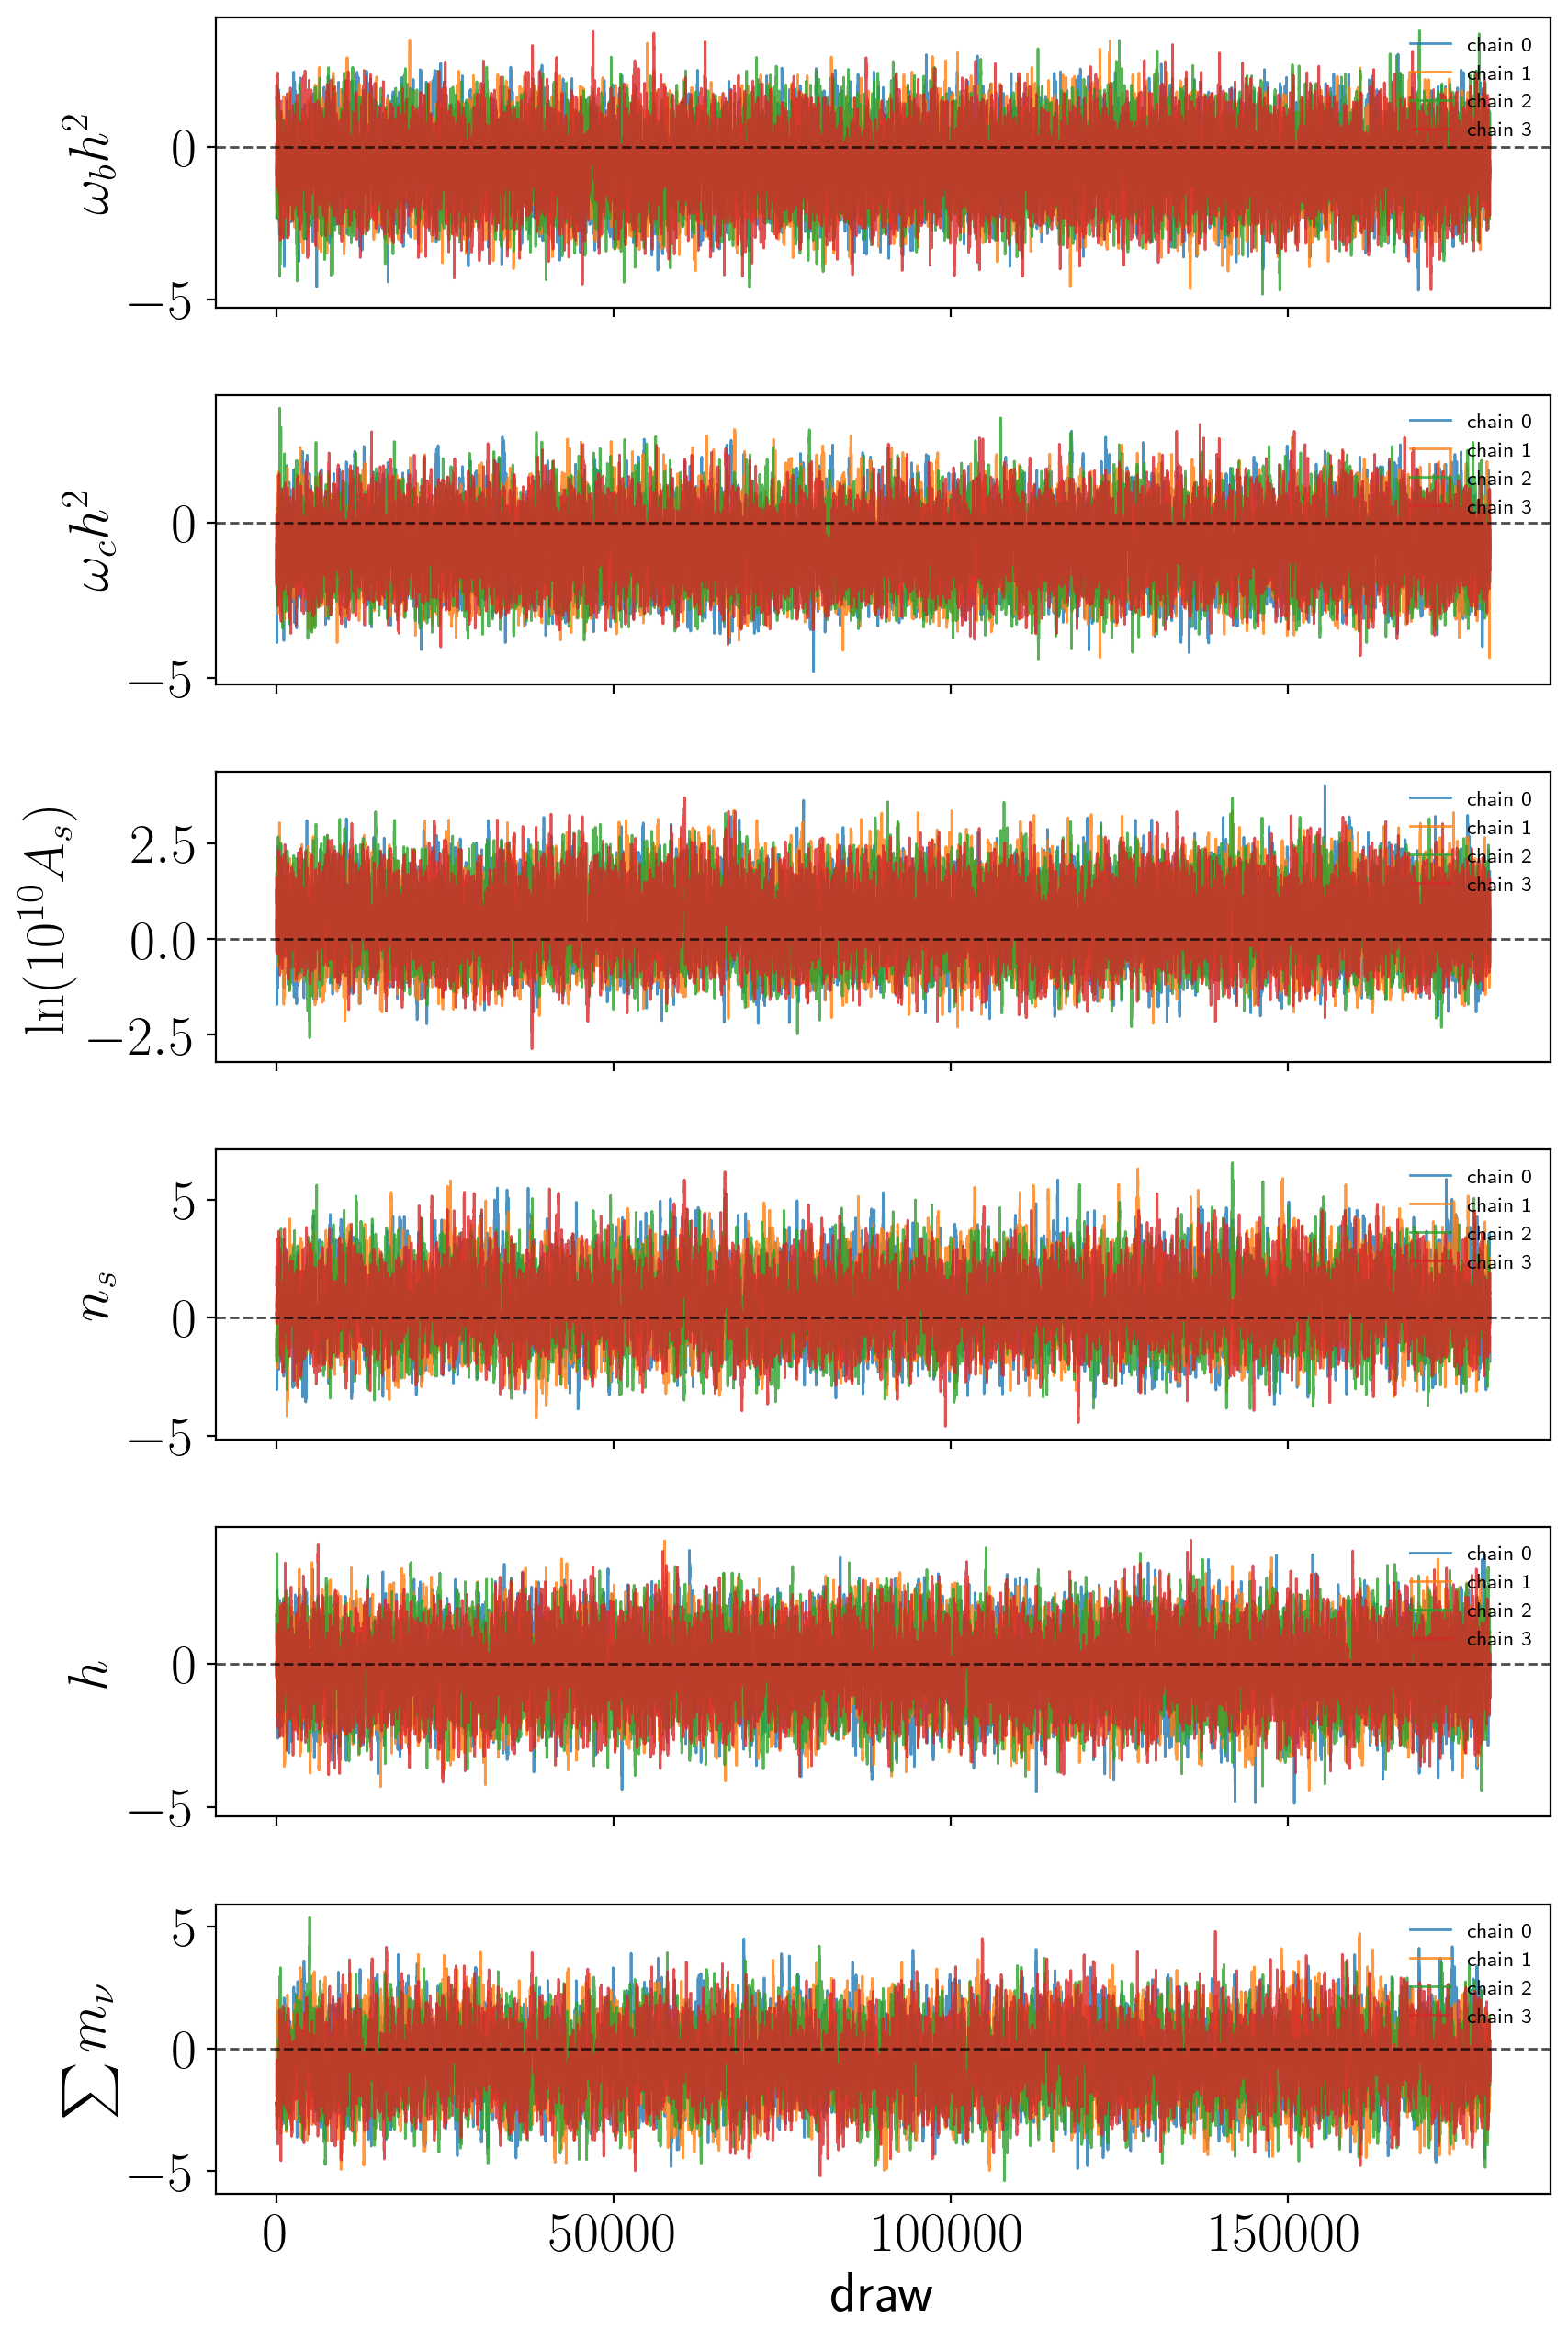

In [13]:
chain_spec = make_fullshape_spec(
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    n_bins=n_zbins, varied_idx=list(split.nl_idx), analysis_kind='joint')
named_w = packed_samples_to_dict(samples_w, chain_spec, chain_axis=0, draw_axis=1)
cosmo_names = [chain_spec.varied_param_names()[i] for i in cosmo_nl_pos]
cosmo_w = {name: named_w[name] for name in cosmo_names}
fig, _ = plot_trace(cosmo_w, var_names=cosmo_names,
                    truths={name: 0.0 for name in cosmo_names},
                    chain_axis=0, draw_axis=1)

## Physical-space posterior and MCMC-vs-Fisher comparison (cosmology)

The Fisher matrix compared against below (`F_pfs_bao_prior_cosmo`) carries the **same DESI
DR1-reanalysis b1σ8 spec + BBN/$n_{s,10}$** as the sampled target, and is built exactly as in
`fisher_joint_PFS_BAO_BBN_ns_nuLCDM.ipynb` — its σ's (including the $m_\nu$ row) should reproduce that
notebook's "PFS P+B+BAO+BBN+ns" column. Read the ratio column with the mean-vs-mode caveat above.

> **In the committed state (`SMOKE_TEST=False`) the numbers below are the converged production
> RWMH-on-surrogate posterior** (4 chains × 180k draws, R-hat $\le 1.0006$). Set `SMOKE_TEST=True` to
> regenerate the short exact-path smoke chain instead (a pipeline check dominated by sampling noise).

For exact-target confirmation of these surrogate posteriors, the delayed-acceptance MH chain in
`scripts/damh_exact_chain_lcdm.py` samples the exact per-bin posterior directly, and importance-sampling
reweighting diagnostics (`ess`, `ess_frac`, `max_weight`) that re-weight a surrogate chain back onto the
exact posterior live in `jaxptpolypol.marginal_taylor` (`importance_reweight`, `reweighted_moments`).

**The $m_\nu$ marginal (bottom-right panel) is a truncated shape by construction, not a detection.** The sampled $m_\nu$ prior is flat with a hard physical wall at $\Sigma m_\nu \ge 0$ (the $-\infty$ indicator in the likelihood cell), and on this noiseless mock the fiducial $m_\nu = 0.06$ eV sits only $\approx 0.5\,\sigma_F$ above that wall ($\sigma_F^{m_\nu}\approx 0.12$ eV), so the posterior is a half-Gaussian-like truncated shape. The validation gate (`scripts/desi_prior_validation.py --cosmology nulcdm`, `cache/nulcdm_gate_fiducial_means.json`) measures this directly: the observed $m_\nu$ chain width is **0.791$\times$** the untruncated Fisher $\sigma$ (vs the 1-D truncated-normal analytic prediction 0.697), with **3.2%** of draws within 0.01 eV of the wall. The narrow $m_\nu$ marginal therefore reflects the prior wall, not information gain. The bound is load-bearing: the unbounded diagnostic (`cache/nulcdm_gate_fiducial_means_unbounded.json`) collapsed to a spurious extrapolation mode at $m_\nu \approx -0.33$ eV, outside the emulator/surrogate domain (verdict **INVALID_CONFIGURATION**), so the physical bound is retained in production.

Note on the two m$_\nu$ width ratios: the 0.791 above is against the marginal-posterior Hessian-Fisher $\sigma$ (0.121 eV); the corner table in the next cell ratios against the Gauss–Newton comparison Fisher $\sigma$ (0.208 eV), giving 0.46. Both use the same chain $\sigma$ = 0.0957 eV — the two Fisher references differ by the $\theta_{\rm NL}$-dependent prior-width curvature absent from the comparison Fisher.


In [14]:
samples_phys = samples_to_physical(samples_w, to_physical)
summary = scalar_summary_packed(samples_phys, chain_spec)

cosmo_flat = np.asarray(samples_phys)[..., cosmo_nl_pos].reshape(-1, N_SHARED)
mcmc_mean = cosmo_flat.mean(axis=0)
mcmc_sigma = cosmo_flat.std(axis=0)
mcmc_cov = np.cov(cosmo_flat, rowvar=False)
fisher_cov = np.asarray(inv(F_pfs_bao_prior_cosmo))   # DESI-spec priors = the target's spec
fisher_sig = np.sqrt(np.diag(fisher_cov))

print("Fisher: PFS P+B + DESI DR2 BAO + BBN/ns10 + DESI DR1-reanalysis EFT priors "
      "(same spec as the sampled target)")
if SMOKE_TEST:
    print(f"!! SMOKE_TEST: {cosmo_flat.shape[0]} draws from the exact-path gate chain -- "
          "the MCMC columns are noise, not a converged posterior.")
print(f"{'param':>7s} {'fid':>10s} {'MCMC mean':>12s} {'Fisher sig':>12s} {'MCMC sig':>12s} {'ratio':>7s}")
for i, key in enumerate(SHARED_KEYS):
    print(f"{key:>7s} {FIDUCIAL_SHARED[i]:10.5g} {mcmc_mean[i]:12.5g} "
          f"{fisher_sig[i]:12.5g} {mcmc_sigma[i]:12.5g} {mcmc_sigma[i]/fisher_sig[i]:7.2f}")

# Residual mean pull relative to Fisher sigma: (MCMC mean - fiducial) / Fisher sig.
# Under fiducial_centered the prior-mean gradient is removed, so this pull is the
# residual VOLUME term (logdet + width-volume + marginal curvature) only.
pulls = (mcmc_mean - FIDUCIAL_SHARED) / fisher_sig
print("residual pulls (volume term only under fiducial_centered): "
      + "  ".join(f"{key}={pulls[i]:+.2f}" for i, key in enumerate(SHARED_KEYS)))

Fisher: PFS P+B + DESI DR2 BAO + BBN/ns10 + DESI DR1-reanalysis EFT priors (same spec as the sampled target)
  param        fid    MCMC mean   Fisher sig     MCMC sig   ratio
  ombh2    0.02242     0.022159   0.00049007   0.00048142    0.98
  omch2    0.11933      0.11655    0.0037231    0.0031929    0.86
   logA      3.047       3.1417      0.13373      0.07915    0.59
     ns     0.9665      0.99687     0.035167     0.033348    0.95
      h     0.6766      0.67289    0.0043906    0.0036401    0.83
    mnu       0.06      0.14849      0.20809     0.096673    0.46
residual pulls (volume term only under fiducial_centered): ombh2=-0.53  omch2=-0.75  logA=+0.71  ns=+0.86  h=-0.84  mnu=+0.43


## Frequentist cross-check: profile likelihood peaks at fiducial

The marginal means above sit $0.4$–$0.9\,\sigma_F$ off fiducial. A profile likelihood isolates whether that is a *fitting* error or a *marginalization* artefact. Where the Bayesian marginal integrates the joint posterior over all other parameters, the profile instead **minimizes** the data $\chi^2$ over them: at each fixed value of one cosmological parameter we re-optimize every other $\theta_{\rm NL}$ dimension and analytically profile out the 11 linear EFT/stochastic amplitudes per bin (an exact whitened GLS, no priors, and no $b_1\sigma_8$ change-of-variables Jacobian or $[0,3]$ walls). Because the mock is *noiseless* — the data vector is exactly the fiducial theory, and the Taylor templates reconstruct that theory exactly at the expansion point — the profiled $\chi^2$ is $0$ at fiducial and non-negative everywhere, so its global minimum sits at fiducial *by construction*. The BAO and BBN($\omega_b$)+$n_{s,10}$ terms are external, fiducial-centered, data-like constraints: centered at truth they cannot move the peak, they only break degeneracies and keep the 1-D profiles well-conditioned. The marginal means nonetheless drift because the Bayesian mean carries a cosmology-dependent **marginalization volume**: the $\ln\det$ of the $\theta_{\rm NL}$-dependent nuisance-prior widths plus the projection of the non-Gaussian joint onto the cosmology subspace tilt the integrated posterior even when the likelihood ridge is flat along fiducial. For $m_\nu$ the grid and the free-dimension optimizer are box-bounded to $m_\nu \ge 0$: this is the emulator/surrogate **validity domain** (the unbounded-$m_\nu$ diagnostic returned INVALID_CONFIGURATION, proving $m_\nu < 0$ is a spurious extrapolation region), not a prior. The table and figure below make the contrast quantitative: profile-min offsets $\approx 0$ against marginal-mean pulls of $0.4$–$0.9\,\sigma_F$.

chi2_prof(fiducial) = 1.048e-23   (noiseless-mock exactness tripwire, expect < 1e-10)



  param   profile-min offset   marginal-mean pull   (units: sigma_F)
  ombh2               -0.000                -0.53
  omch2                0.006                -0.75
   logA               -0.011                 0.71
     ns                0.001                 0.86
      h                0.004                -0.84
    mnu               -0.003                 0.43

[PASS] max |profile-min offset| = 0.011 sigma_F (< 0.1 tol) vs marginal-mean pulls |.| in [0.43, 0.86] sigma_F -- the likelihood peaks at fiducial; the pulls are marginalization-volume effects.
profile computation wall time: 129.2 s


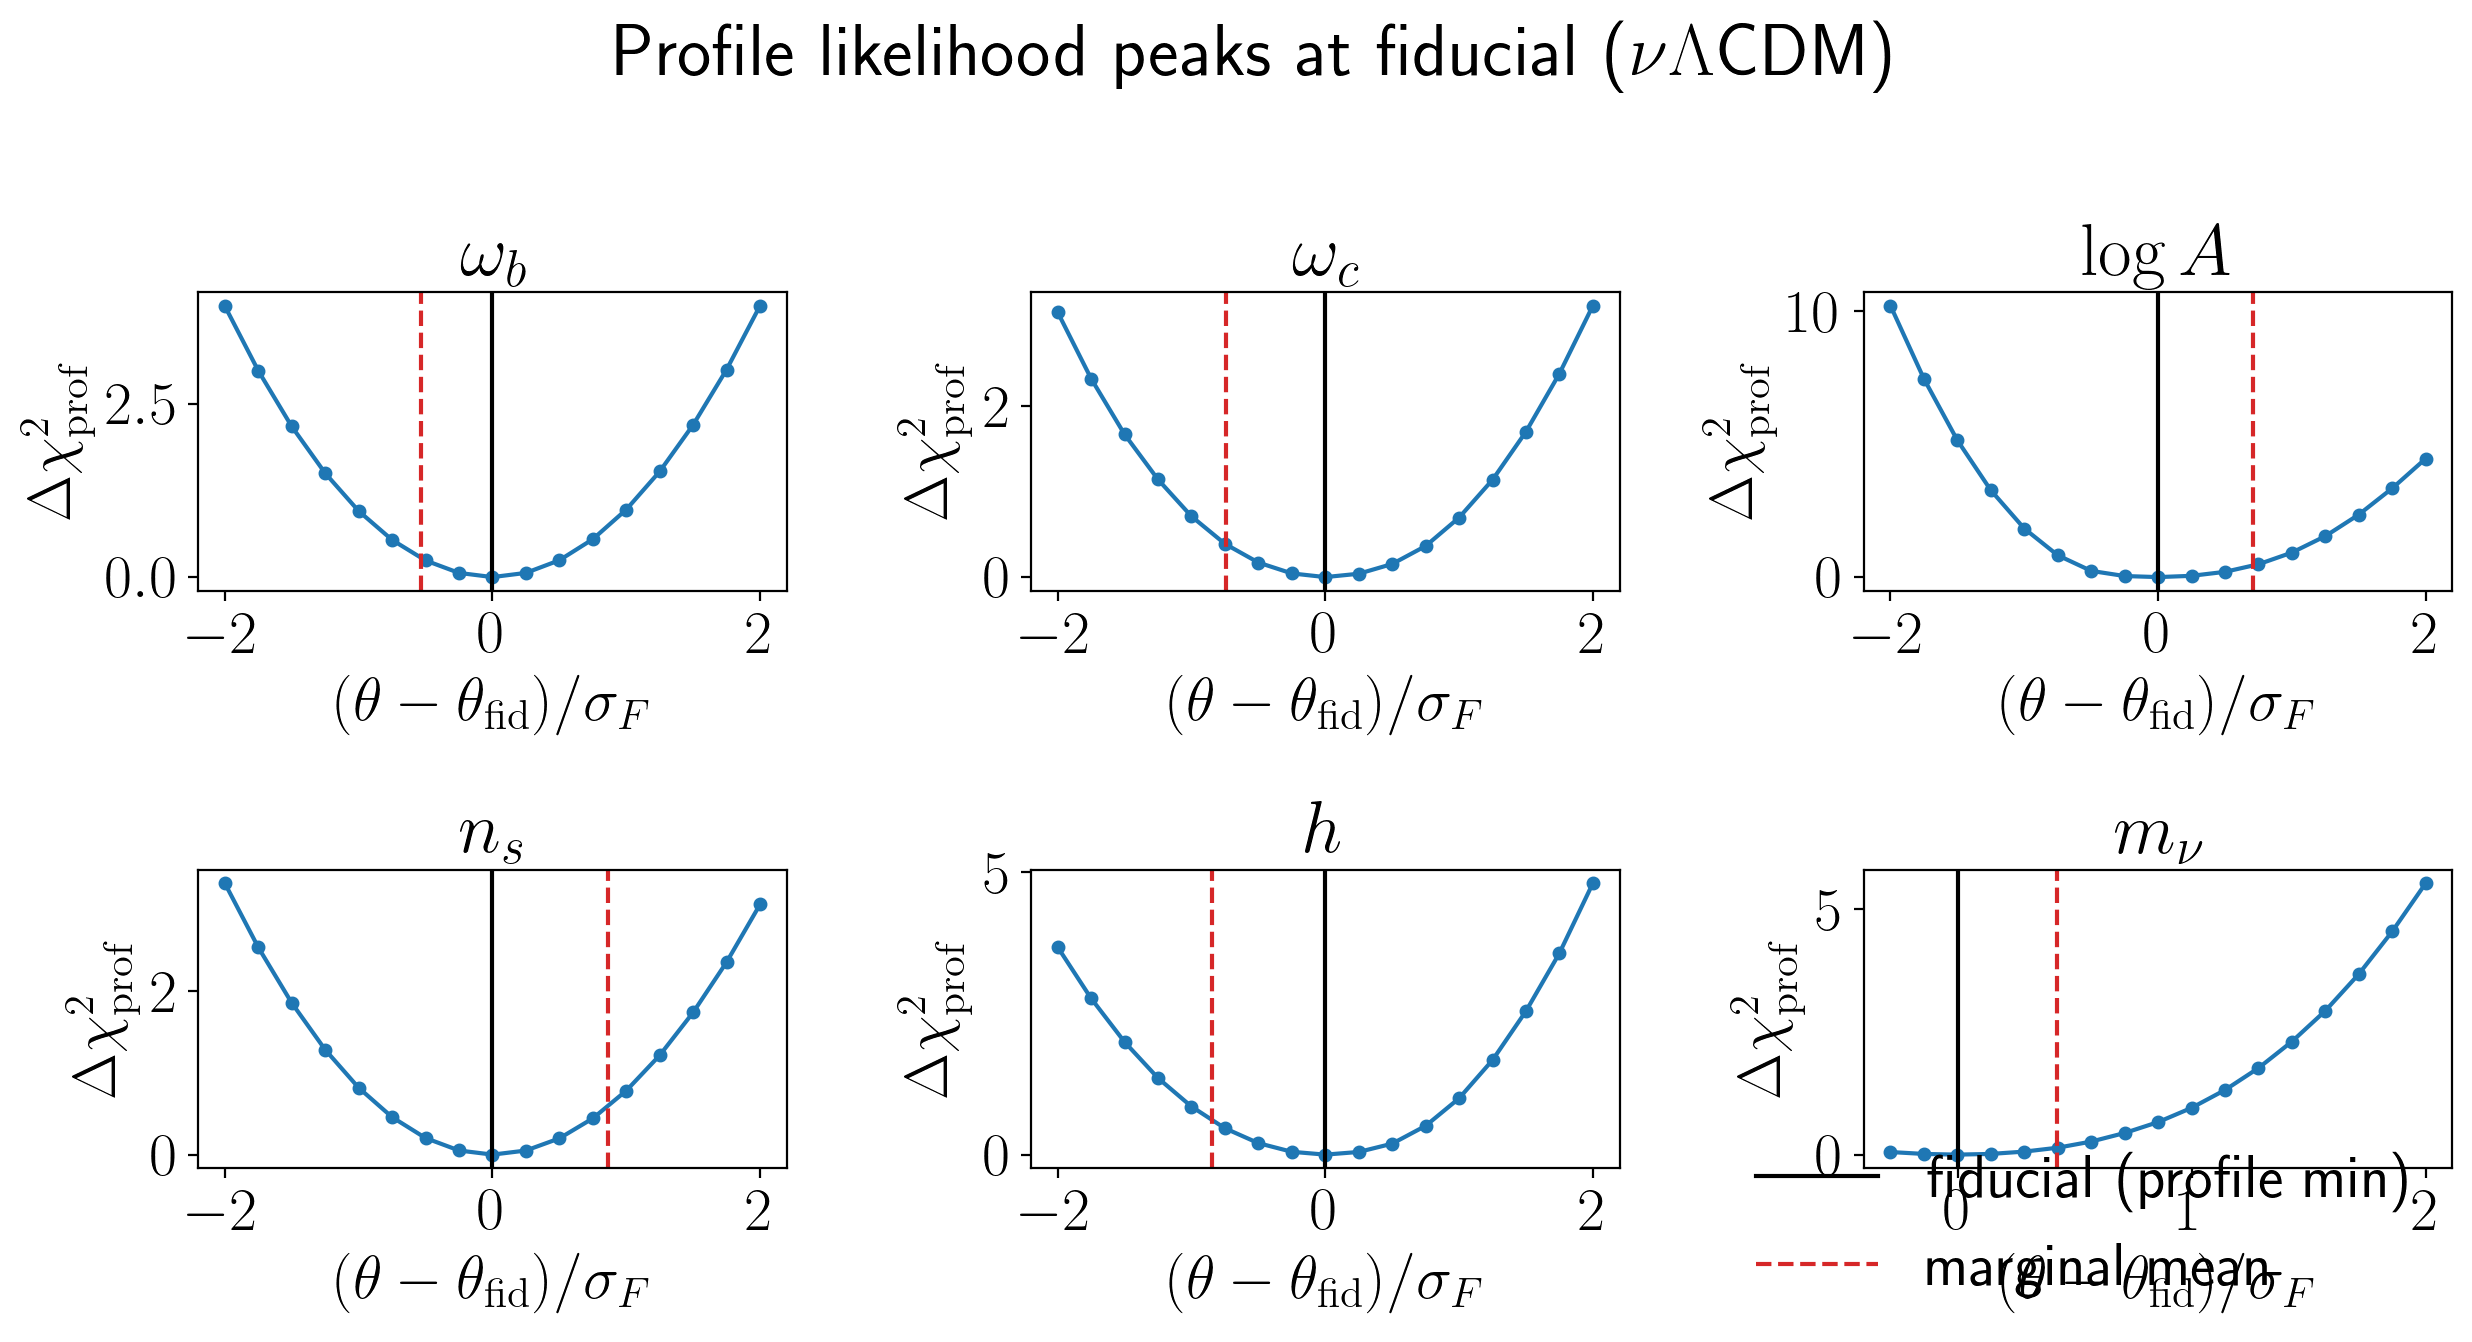

In [15]:
# ============================================================================
# Frequentist profile-likelihood check: the DATA likelihood peaks at fiducial
# ----------------------------------------------------------------------------
# Objective (DATA terms ONLY -- no theta_lin priors, no b1sigma8 Jacobian/[0,3]
# walls, no mnu prior): the profiled chi-square on the Taylor surrogate,
#   chi2_prof(theta_NL) = min_theta_lin ||W (d - m0(theta_NL) - M(theta_NL) theta_lin)||^2
#                         + chi2_BAO(theta_NL) + chi2_BBN_ns(theta_NL)
# The inner min over the 11 linear EFT/stochastic params per bin is an EXACT
# whitened GLS (per-bin W_b with W_b^T W_b = Cinv_b; solved by jnp.linalg.lstsq).
# BAO + BBN(ombh2) + ns10 are external, fiducial-centered, data-like constraints:
# centered at fiducial they cannot move the peak -- they only break degeneracies
# and keep the 1-D profiles well-conditioned. We reuse the notebook's own Taylor
# templates (_tt), whitened data (bin_data / bin_cov_invs), BAO term, and the
# BBN/ns10 entries (nl_prior_entries); no pipeline is rebuilt here.
from scipy.optimize import minimize

t_prof0 = time.time()

theta0_nl = jnp.asarray(_tt.theta0)                    # physical theta_NL fiducial (== fid_nl)
_order2 = _tt.order2_m0
# Per-bin whitening: Cinv_b = L L^T (lower Cholesky) => W_b = L^T, ||W_b r||^2 = r^T Cinv_b r.
W_bins = [jnp.linalg.cholesky(jnp.asarray(ci)).T for ci in bin_cov_invs]
bao_cov_inv_j = jnp.asarray(bao_cov_inv)
_nl_pos = jnp.array([int(e[0]) for e in nl_prior_entries])       # BBN(ombh2)+ns10 theta_NL positions
_nl_mu = jnp.array([float(e[1]) for e in nl_prior_entries])      # centered at fiducial
_nl_sig = jnp.array([float(e[2]) for e in nl_prior_entries])


@jax.jit
def chi2_prof(theta_nl):
    delta = theta_nl - theta0_nl
    chi2 = 0.0
    for b in range(len(W_bins)):
        m0 = _tt.bin_m00[b] + _tt.bin_J[b] @ delta
        if _order2:
            m0 = m0 + 0.5 * jnp.einsum("ijk,j,k->i", _tt.bin_H[b], delta, delta)
        M = _tt.bin_M0[b] + jnp.einsum("ijk,k->ij", _tt.bin_dM[b], delta)
        y = W_bins[b] @ (bin_data[b] - m0)             # whitened residual (theta_lin=0)
        X = W_bins[b] @ M                              # whitened template matrix
        sol = jnp.linalg.lstsq(X, y, rcond=None)[0]    # exact GLS profile-out of theta_lin
        res = y - X @ sol
        chi2 = chi2 + jnp.sum(res * res)
    # BAO (theta_lin-independent; evaluated on the full packed vector, fiducial-centered)
    r_bao = bao_fid - bao_theory_fn(full_params_fn(theta_nl)[:n_cosmo_params])
    chi2 = chi2 + r_bao @ bao_cov_inv_j @ r_bao
    # BBN(ombh2) + ns10 Gaussian data-like terms, centered at fiducial
    chi2 = chi2 + jnp.sum(((theta_nl[_nl_pos] - _nl_mu) / _nl_sig) ** 2)
    return chi2


# Exactness tripwire: the noiseless mock IS the fiducial theory and the templates
# reconstruct it exactly at the expansion point, so chi2_prof(fiducial) = 0 to the
# float64 floor; with chi2_prof >= 0 everywhere the global profile minimum is at
# fiducial BY CONSTRUCTION. The check's job is to show the 1-D profiles are smooth
# parabolas with minima at fiducial, in visible contrast to the pulled marginal means.
chi2_fid = float(jax.block_until_ready(chi2_prof(theta0_nl)))
print(f"chi2_prof(fiducial) = {chi2_fid:.3e}   (noiseless-mock exactness tripwire, expect < 1e-10)")
assert chi2_fid < 1e-10, f"profile objective not exact at fiducial: {chi2_fid}"

_val_and_grad = jax.jit(jax.value_and_grad(chi2_prof))
_theta0_np = np.asarray(theta0_nl)

has_mnu = 'mnu' in SHARED_KEYS
mnu_pos = cosmo_nl_pos[SHARED_KEYS.index('mnu')] if has_mnu else None
# Box every FREE cosmo dim to fid +/- K_BOX*sigma_F. This is a numerical validity
# safeguard, not a prior: the profile minimum is at fiducial (chi2 = 0) and the
# 1-D ridge stays within a few sigma_F, but the UNbounded optimizer can overshoot a
# free cosmo dim into a region where the background distance integral (bao_theory_fn)
# is undefined (NaN) -- exactly analogous to the mnu >= 0 emulator/surrogate validity
# bound. Bias dims never enter the background, so they are left free.
K_BOX = 6.0
cosmo_fid = {cosmo_nl_pos[m]: float(FIDUCIAL_SHARED[m]) for m in range(N_SHARED)}
cosmo_sig = {cosmo_nl_pos[m]: float(fisher_sig[m]) for m in range(N_SHARED)}

N_GRID = 5 if SMOKE_TEST else 17                        # coarse grid under SMOKE
prof_grids, prof_chi2_vals, prof_offsets = [], [], []

for i, key in enumerate(SHARED_KEYS):
    p_pos = cosmo_nl_pos[i]
    fid_i = float(FIDUCIAL_SHARED[i])
    sig_i = float(fisher_sig[i])
    if key == 'mnu':
        # mnu >= 0 is the emulator/surrogate VALIDITY domain (the unbounded-mnu
        # diagnostic proved mnu < 0 is a spurious extrapolation region), not a prior.
        grid = np.linspace(0.0, fid_i + 2.0 * sig_i, N_GRID)
    else:
        grid = np.linspace(fid_i - 2.0 * sig_i, fid_i + 2.0 * sig_i, N_GRID)

    free_pos = np.array([j for j in range(n_nl) if j != p_pos])
    bounds = []
    for j in free_pos:
        if j in cosmo_fid:                                 # box free cosmo dims (validity)
            lo = cosmo_fid[j] - K_BOX * cosmo_sig[j]
            hi = cosmo_fid[j] + K_BOX * cosmo_sig[j]
            if has_mnu and j == mnu_pos:
                lo = max(lo, 0.0)                          # mnu >= 0 validity domain
            bounds.append((lo, hi))
        else:
            bounds.append((None, None))                   # bias dims free

    def _scipy_obj(x_free, v, _fp=free_pos, _pp=p_pos):
        theta = _theta0_np.copy()
        theta[_fp] = x_free
        theta[_pp] = v
        val, g = _val_and_grad(jnp.asarray(theta))
        return float(val), np.asarray(g, dtype=np.float64)[_fp]

    chi2_vals = np.empty(N_GRID)
    kc = int(np.argmin(np.abs(grid - fid_i)))          # grid point nearest fiducial
    r = minimize(_scipy_obj, _theta0_np[free_pos], args=(grid[kc],),
                 method="L-BFGS-B", jac=True, bounds=bounds)
    chi2_vals[kc] = r.fun
    x_center = r.x
    x_prev = x_center                                   # warm-start outward (up) from the center
    for k in range(kc + 1, N_GRID):
        r = minimize(_scipy_obj, x_prev, args=(grid[k],), method="L-BFGS-B", jac=True, bounds=bounds)
        chi2_vals[k] = r.fun; x_prev = r.x
    x_prev = x_center                                   # warm-start outward (down) from the center
    for k in range(kc - 1, -1, -1):
        r = minimize(_scipy_obj, x_prev, args=(grid[k],), method="L-BFGS-B", jac=True, bounds=bounds)
        chi2_vals[k] = r.fun; x_prev = r.x

    # Locate the profile minimum by a parabola through the 3 points bracketing the smallest.
    km = int(np.argmin(chi2_vals))
    if 0 < km < N_GRID - 1:
        a2, a1, _ = np.polyfit(grid[km - 1:km + 2], chi2_vals[km - 1:km + 2], 2)
        x_min = (-a1 / (2.0 * a2)) if a2 > 0 else grid[km]
    else:
        x_min = grid[km]
    prof_grids.append(grid)
    prof_chi2_vals.append(chi2_vals)
    prof_offsets.append((x_min - fid_i) / sig_i)

prof_offsets = np.array(prof_offsets)
prof_wall = time.time() - t_prof0

# --- Table: profile-min offset vs marginal-mean pull (both in sigma_F) --------
print(f"\n{'param':>7s} {'profile-min offset':>20s} {'marginal-mean pull':>20s}   (units: sigma_F)")
for i, key in enumerate(SHARED_KEYS):
    print(f"{key:>7s} {prof_offsets[i]:>20.3f} {pulls[i]:>20.2f}")

max_off = float(np.max(np.abs(prof_offsets)))
min_pull = float(np.min(np.abs(pulls)))
# The PRODUCTION criterion is |offset| < 0.1 sigma_F at the 17-point grid (validated: the
# offsets are 0.001-0.01 sigma_F there). Under SMOKE the coarse grid cannot localize a
# BROAD profile's vertex (logA, mnu) to 0.1 sigma -- the parabola-through-3-grid-points
# estimate is grid-resolution limited -- so the smoke gate is loosened to 0.5 sigma. A
# broken profile (a NaN or a genuinely off-fiducial min -> argmin at a grid edge -> offset
# ~= 2 sigma) still trips it, so the smoke keeps its machinery-sanity value.
prof_tol = 0.5 if SMOKE_TEST else 0.1
profile_ok = max_off < prof_tol
print(f"\n[{'PASS' if profile_ok else 'FAIL'}] max |profile-min offset| = {max_off:.3f} sigma_F "
      f"(< {prof_tol} tol) vs marginal-mean pulls |.| in [{min_pull:.2f}, {float(np.max(np.abs(pulls))):.2f}] sigma_F "
      f"-- the likelihood peaks at fiducial; the pulls are marginalization-volume effects.")
print(f"profile computation wall time: {prof_wall:.1f} s")
assert profile_ok, (
    f"profile-min offset exceeds {prof_tol} sigma_F (max={max_off:.3f}); investigate optimizer "
    "convergence before loosening -- a converged violation falsifies the check's premise.")

# --- Figure: Delta chi2 profile per parameter (small multiples) ---------------
_ncol = 3
_nrow = int(np.ceil(N_SHARED / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(4.2 * _ncol, 3.4 * _nrow))
axes = np.atleast_1d(axes).ravel()
for i, key in enumerate(SHARED_KEYS):
    ax = axes[i]
    x_sig = (prof_grids[i] - float(FIDUCIAL_SHARED[i])) / float(fisher_sig[i])
    ax.plot(x_sig, prof_chi2_vals[i] - np.min(prof_chi2_vals[i]), 'o-', color='C0', ms=4)
    ax.axvline(0.0, color='k', ls='-', lw=1.5)                 # fiducial (profile peak)
    ax.axvline(pulls[i], color='C3', ls='--', lw=1.5)         # marginal mean
    ax.set_title(SHARED_LABELS[i])
    ax.set_xlabel(r'$(\theta-\theta_{\rm fid})/\sigma_F$')
    ax.set_ylabel(r'$\Delta\chi^2_{\rm prof}$')
for j in range(N_SHARED, len(axes)):
    axes[j].axis('off')
_solid = mlines.Line2D([], [], color='k', ls='-', lw=1.5, label='fiducial (profile min)')
_dash = mlines.Line2D([], [], color='C3', ls='--', lw=1.5, label='marginal mean')
fig.legend(handles=[_solid, _dash], loc='lower right', bbox_to_anchor=(0.98, 0.02), frameon=False)
fig.suptitle(rf'Profile likelihood peaks at fiducial ({MODEL_TITLE})', y=1.0)
fig.tight_layout()
plt.show()

  param    68% lower    68% upper    95% lower    95% upper
  ombh2     0.021685     0.022642     0.021223     0.023109
  omch2     0.113267     0.119632     0.110414     0.122852
   logA     3.059334     3.217368     2.989041     3.297562
     ns     0.961490     1.026681     0.932962     1.064406
      h     0.669309     0.676554     0.665867     0.680135
    mnu     0.000356     0.192091     0.000003     0.324258


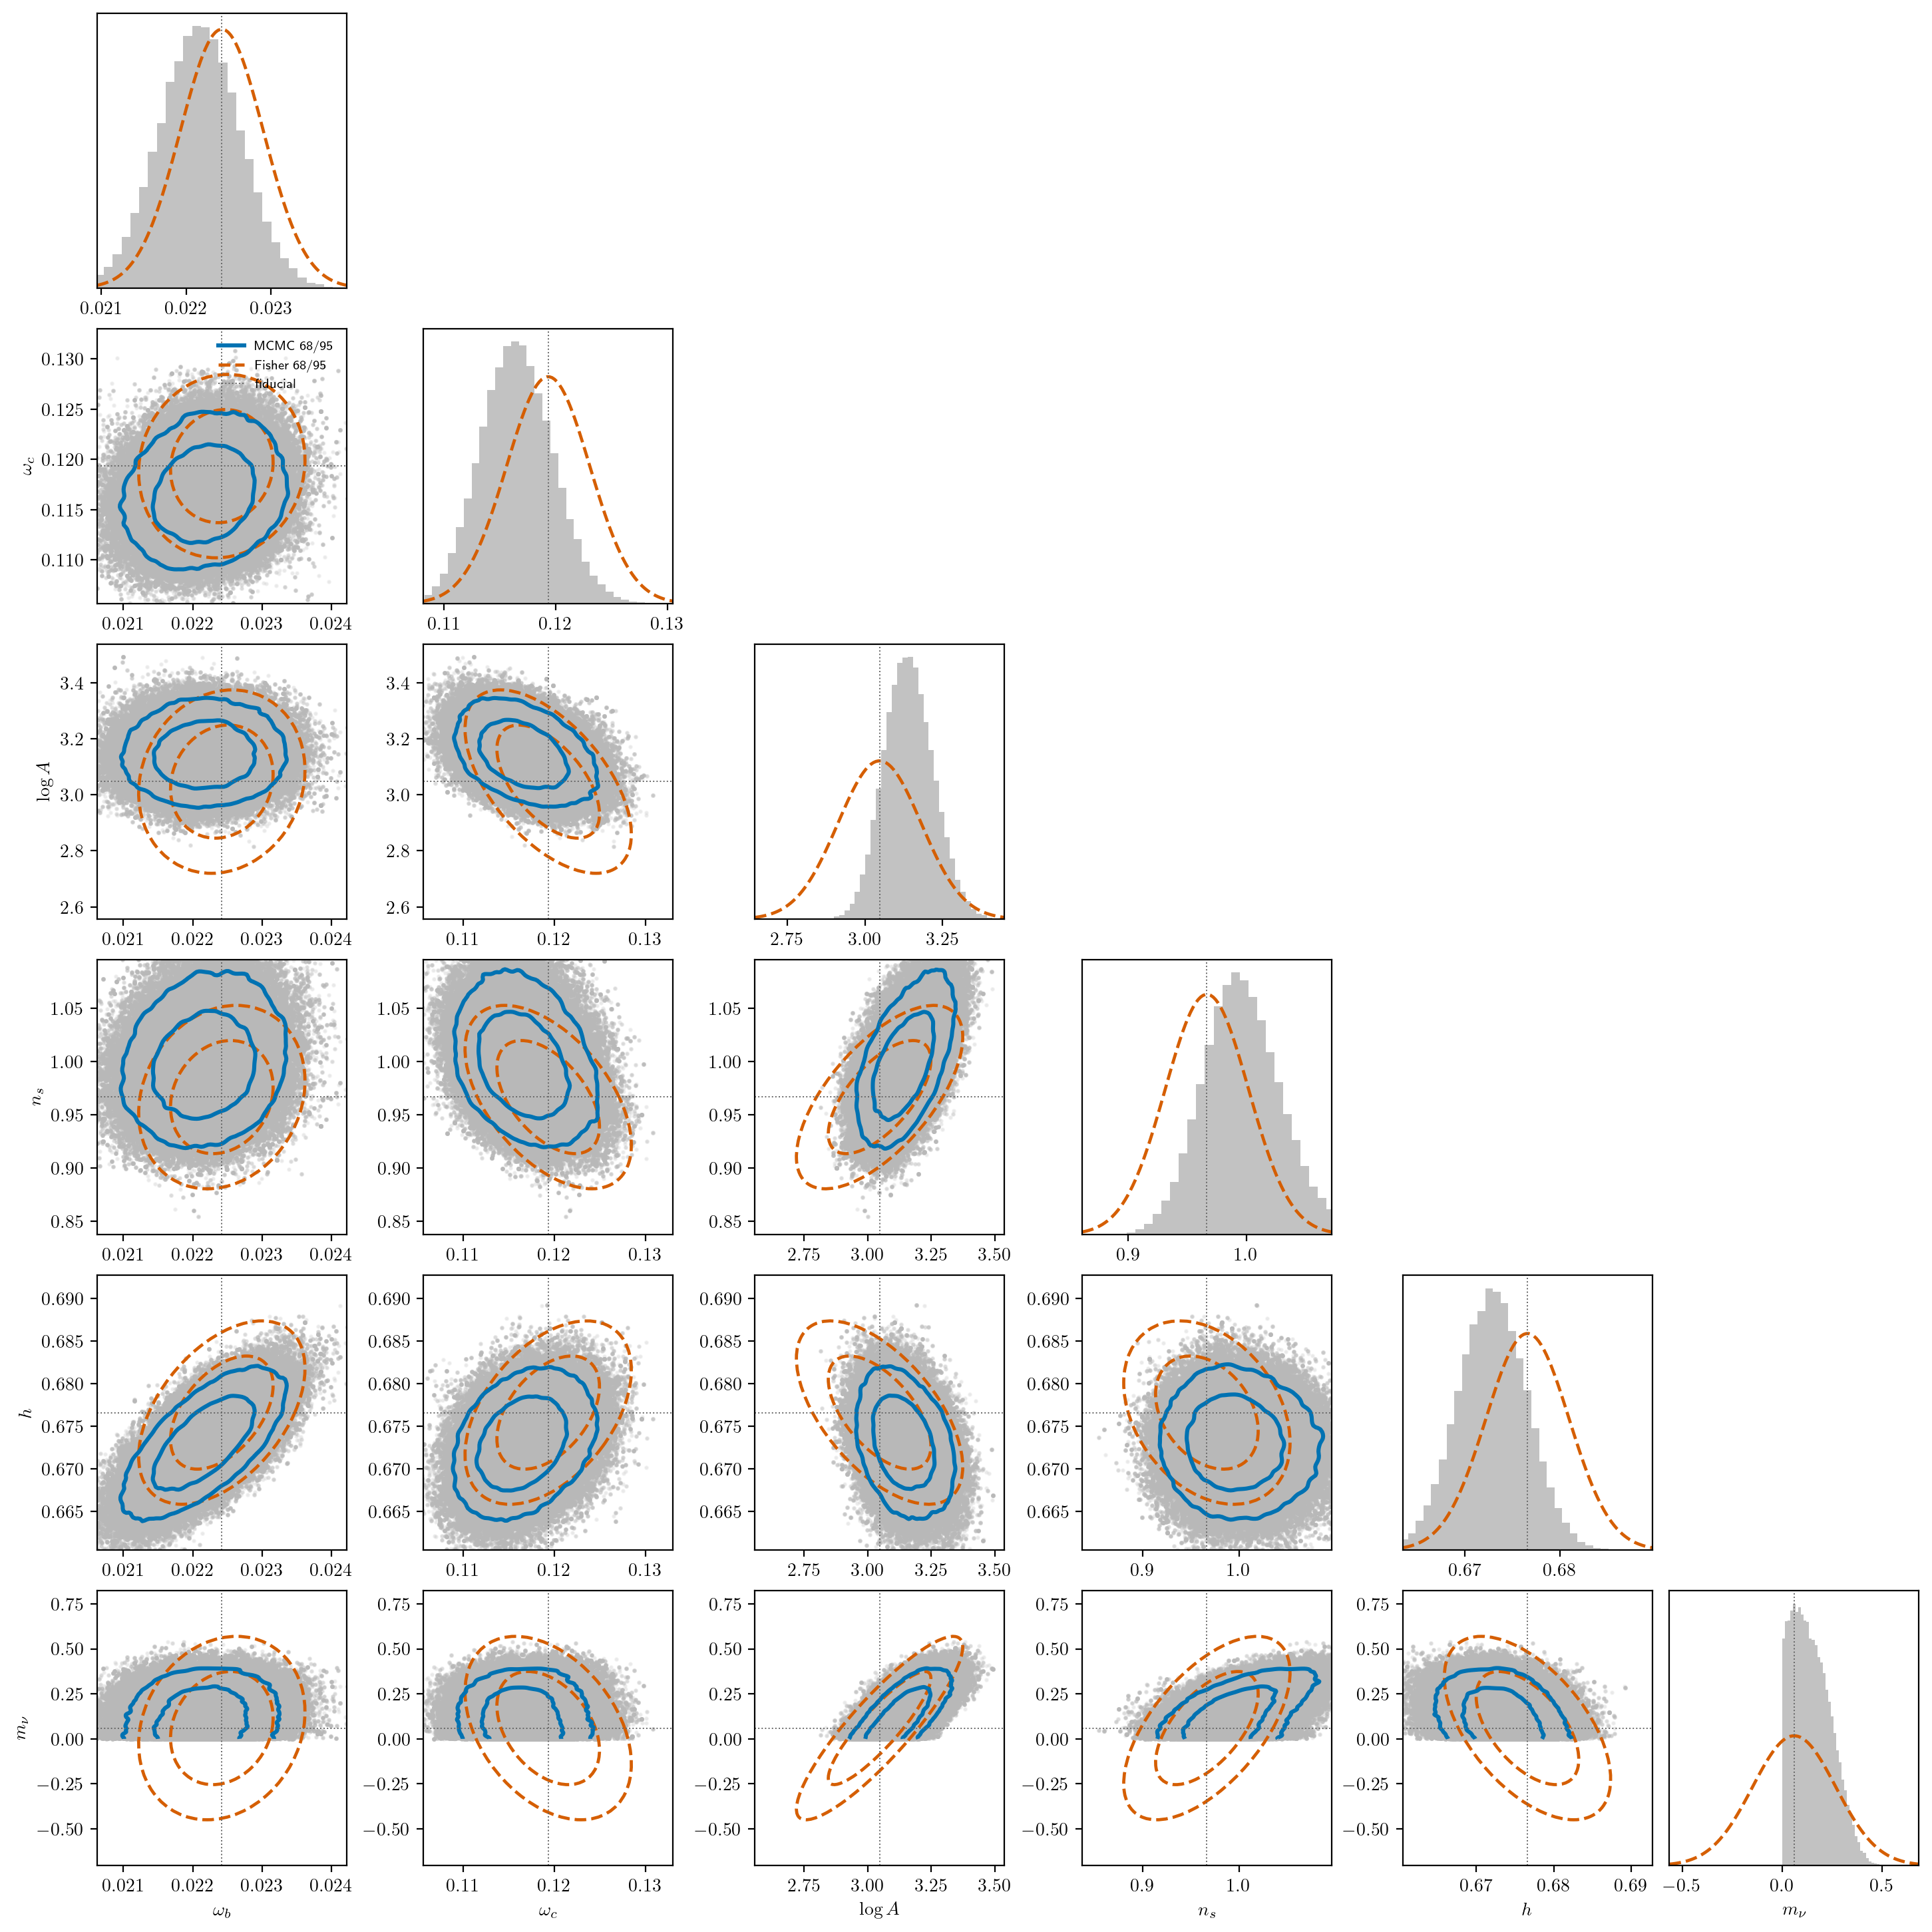

In [16]:
# Cosmology corner: MCMC samples (blue) vs Fisher+prior ellipses (red dashed), both at the
# fiducial. The Fisher ellipses use the DESI-spec comparison Fisher (the target's own priors).
plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(N_SHARED * 2.4, N_SHARED * 2.4), constrained_layout=True)
handles = [mlines.Line2D([], [], color='#0072B2', lw=2.2,
                          label='MCMC 68/95% (2-D HDI)'),
           mlines.Line2D([], [], color='#D55E00', ls='--', lw=1.7,
                          label='Fisher 68/95% (2-D)'),
           mlines.Line2D([], [], color='0.4', lw=0.7, ls=':', label='fiducial')]
for i in range(N_SHARED):
    for j in range(N_SHARED):
        ax = plt.subplot(N_SHARED, N_SHARED, i * N_SHARED + j + 1)
        if j < i:
            ax.scatter(cosmo_flat[:, j], cosmo_flat[:, i], s=2, alpha=0.18,
                       color='0.72', rasterized=True)
            plot_credible_contours(cosmo_flat[:, j], cosmo_flat[:, i],
                                   ax=ax, levels=(0.68, 0.95),
                                   colors='#0072B2', linewidths=2.2, linestyles=('-', '-'))
            plot_contours(F_pfs_bao_prior_cosmo, FIDUCIAL_SHARED, np.array([j, i]),
                          cls=[0.68, 0.95], level_kind="mass2d",
                          ax=ax, fill=False, color='#D55E00', ls='--', lw=1.7)
            ax.axvline(FIDUCIAL_SHARED[j], color='0.4', lw=0.7, ls=':')
            ax.axhline(FIDUCIAL_SHARED[i], color='0.4', lw=0.7, ls=':')
            if i == 1 and j == 0:
                ax.legend(handles=handles, fontsize=7, frameon=False, loc='best')
        elif j == i:
            ax.hist(cosmo_flat[:, i], bins=40, density=True, color='0.72', alpha=0.85)
            plot_Gaussian(F_pfs_bao_prior_cosmo, FIDUCIAL_SHARED, i, ax=ax, color='#D55E00', ls='--', lw=1.7, density=True)
            ax.axvline(FIDUCIAL_SHARED[i], color='0.4', lw=0.7, ls=':')
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == N_SHARED - 1: ax.set_xlabel(SHARED_LABELS[j])
        if j == 0 and i > 0: ax.set_ylabel(SHARED_LABELS[i])
# 68/95% credible intervals (1-D, diagonal-panel convention). NOTE the
# asymmetry with the contours above: the 68% 1-D interval is the 1-sigma
# interval, while the 68% 2-D contour sits at 1.5096 sigma.
_ci = credible_intervals(
    {k: cosmo_flat[:, n] for n, k in enumerate(SHARED_KEYS)},
    var_names=list(SHARED_KEYS), levels=(0.68, 0.95), draw_axis=0, chain_axis=None)
print(f"{'param':>7s} {'68% lower':>12s} {'68% upper':>12s} "
      f"{'95% lower':>12s} {'95% upper':>12s}")
for _k in SHARED_KEYS:
    _l68, _u68 = _ci[_k][0.68]
    _l95, _u95 = _ci[_k][0.95]
    print(f"{_k:>7s} {_l68:12.6f} {_u68:12.6f} {_l95:12.6f} {_u95:12.6f}")

## Derived-parameter projection: $(\Sigma m_\nu, \Omega_m, \sigma_8, H_0)$

The sampled cosmology is native -- $(\omega_b, \omega_c, \log A, n_s, h, \Sigma m_\nu)$ -- while forecasts are usually quoted in the
derived basis $(\Sigma m_\nu, \Omega_m, \sigma_8, H_0)$. Both the chain and the comparison Fisher are pushed through **one**
differentiable map, `jaxptpolypol.derived.make_lcdm_derived_params_fn` (the same helper the
`fisher_joint_*` notebooks project with), so the sample clouds and the Fisher ellipses below
cannot disagree by construction. $\Omega_m = (\omega_b + \omega_c + \Sigma m_\nu / 93.14)/h^2$ and
$H_0 = 100\,h$ are exact identities (asserted at the fiducial); $\sigma_8$ is the $z = 0$ top-hat
variance of the emulator's linear $P(k)$ and is printed, not asserted.

The MCMC columns are the sample mean/std of the projected chain. The Fisher column is
$\sqrt{\mathrm{diag}(J C J^{\mathsf{T}})}$ with $C$ the native comparison covariance
(`F_pfs_bao_prior_cosmo`) and $J$ the map's Jacobian at the fiducial. Native parameters that do not enter
the map (the per-bin bias block and the analytically marginalized $\theta_{\rm lin}$) are marginalized simply by being absent from it -- their correlations still
propagate through $C$.

The $\Sigma m_\nu$ row is an **identity coordinate** of the map (asserted bit-identical to the
chain's $m_\nu$ column), so its MCMC/Fisher ratio restates the truncated-marginal caveat of the
table above verbatim -- a Gauss-Newton-flavored $\sigma_F$ against a chain width truncated by the
$\Sigma m_\nu \ge 0$ wall. Never quote it as a bare Gaussian width, and never mix it with the
Hessian-flavored $\sigma_F$.


derived fiducial: Omega_m = 0.311049, sigma8 = 0.810337, H0 = 67.6600  (sigma8 = z=0 top-hat variance of the emulator P_lin)

Derived basis: mnu , Omega_m , sigma8 , H0  |  Fisher = F_pfs_bao_prior_cosmo projected through the same map
    param        fid    MCMC mean   Fisher sig     MCMC sig   ratio
      mnu       0.06      0.14849      0.20809     0.096673    0.46
  Omega_m    0.31105      0.30988    0.0081677    0.0073905    0.90
   sigma8    0.81034      0.82758     0.023935     0.025116    1.05
       H0      67.66       67.289      0.43906      0.36401    0.83
residual pulls (sigma_F units): mnu=+0.43  Omega_m=-0.14  sigma8=+0.72  H0=-0.84
NOTE mnu: identity coordinate -- its ratio restates the TRUNCATED-marginal caveat of the table above (Gauss-Newton-flavored sigma_F vs a chain width cut by the mnu >= 0 wall); never quote it as a bare Gaussian width, never mix sigma_F flavors.


  param    68% lower    68% upper    95% lower    95% upper
    mnu     0.000356     0.192091     0.000003     0.324258
Omega_m     0.302205     0.316856     0.295544     0.324524
 sigma8     0.802485     0.852204     0.779330     0.877905
     H0    66.930936    67.655437    66.586657    68.013485


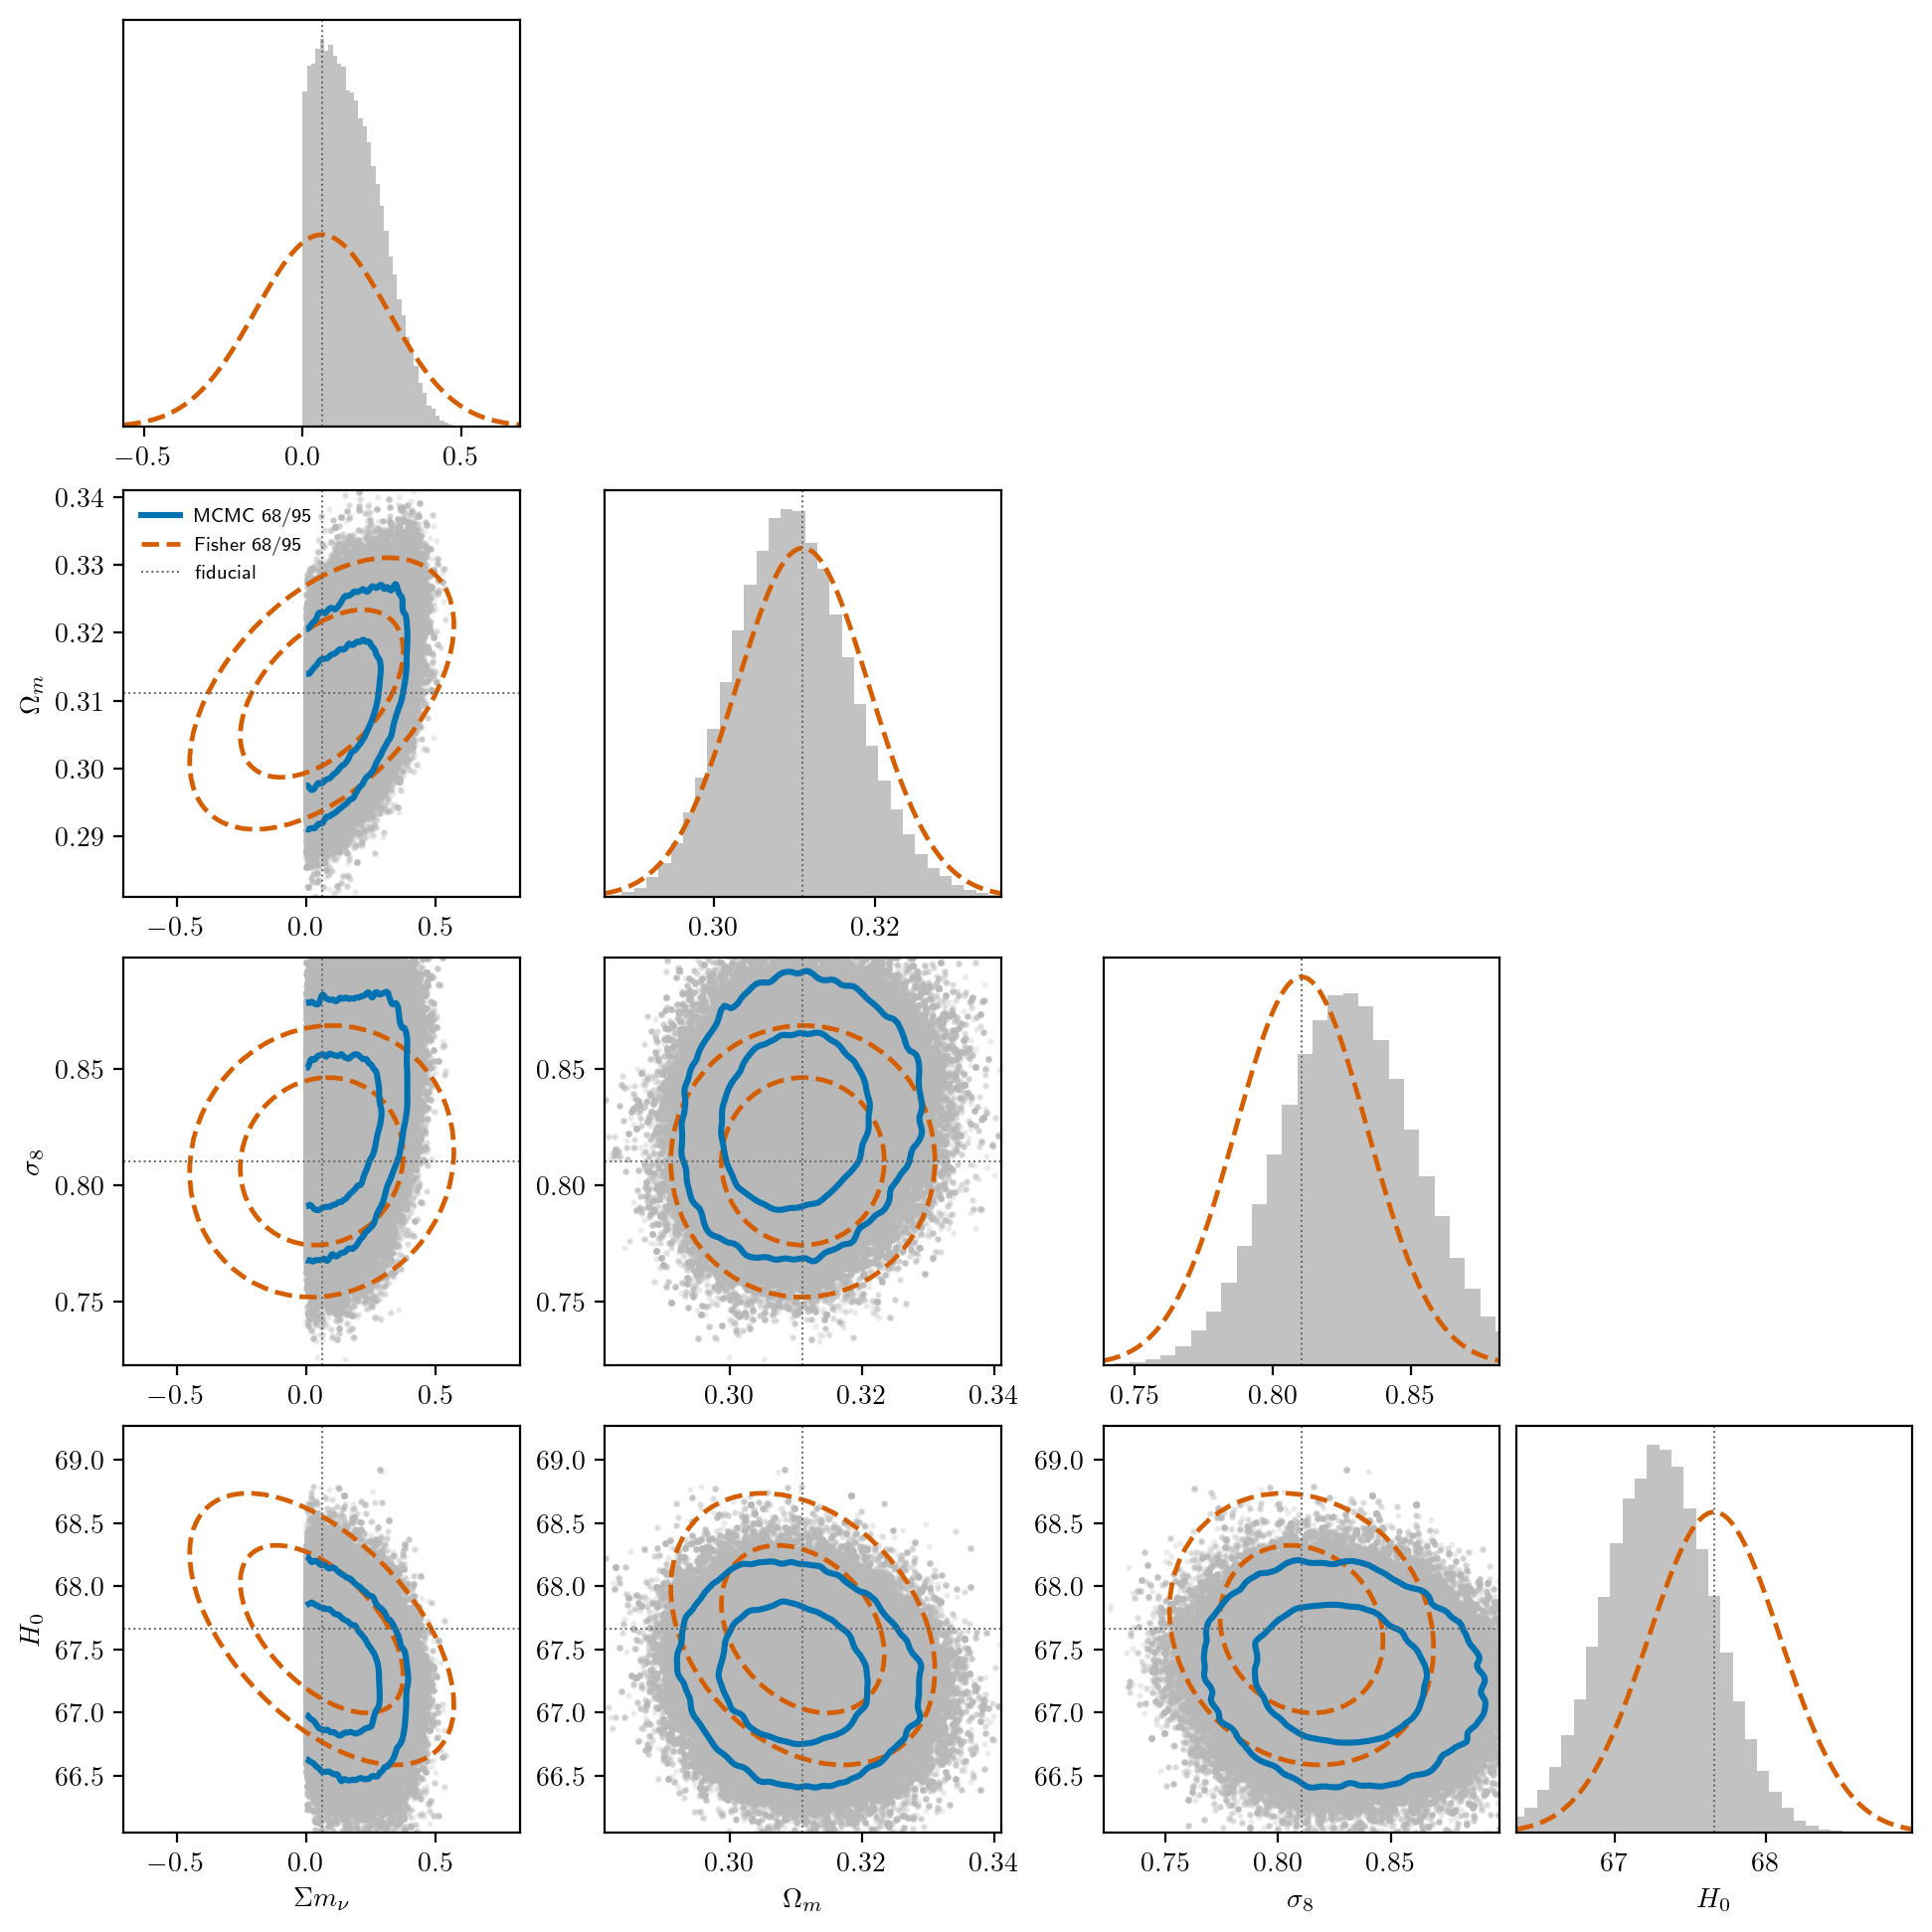

In [17]:
# ── Derived-parameter projection: (mnu, Omega_m, sigma8, H0) ──────────────────────
# ONE differentiable map carries BOTH the chain and the comparison Fisher into the
# derived basis, so the clouds and the ellipses below agree by construction. The whole
# wrapper lives in the library now (jaxptpolypol.derived.make_derived_projection_fn):
# native-slot scatter, the (Omega_m, H0, sigma8) call, the reorder to the reported axis
# order, the identity coordinate mnu prepended. Native parameters absent from the map (the bias block, theta_lin)
# are marginalized by simply not entering it, while their correlations still widen the
# projected covariance through C = F^-1.
from jaxptpolypol.derived import (format_derived_comparison_rows,
                                  make_derived_projection_fn)
from jaxptpolypol.inference import project_fisher_to_derived
from jaxptpolypol.cmb_mcmc_utils import chunked_map

DERIVED_LABELS = (r'$\Sigma m_\nu$', r'$\Omega_m$', r'$\sigma_8$', r'$H_0$')
DERIVED_SRC    = list(range(N_SHARED))   # positions in the comparison basis ...
DERIVED_NATIVE = list(cosmo_varied_global)   # ... -> slots of the native cosmo vector
assert len(DERIVED_SRC) == len(DERIVED_NATIVE)
_mnu_nat = cosmo.param_keys.index('mnu')                  # mnu slot, native cosmo vector
_mnu_src = DERIVED_SRC[DERIVED_NATIVE.index(_mnu_nat)]    # ... and in the comparison basis

_fid_native = jnp.asarray(packed_params[:n_cosmo_params], dtype=jnp.float64)
derived_fn, DERIVED_NAMES = make_derived_projection_fn(
    cosmo.param_keys, cosmo.param_sizes, pklin_emulator=pklin_emulator,
    fiducial_native=_fid_native, source_indices=DERIVED_SRC,
    native_indices=DERIVED_NATIVE, mnu_fixed=MNU_FIXED,
    sigma8_redshift=0.0)                               # sigma8 at z = 0
assert DERIVED_NAMES == ('mnu', 'Omega_m', 'sigma8', 'H0')   # reported axis order
assert len(DERIVED_LABELS) == len(DERIVED_NAMES)

# Chain -> derived (chunked; the emulator forward is a vectorized NN).
derived_flat  = chunked_map(cosmo_flat, jax.jit(jax.vmap(derived_fn)), chunk_size=20_000)
assert np.all(np.isfinite(derived_flat)), "projected chain has non-finite entries"
assert np.array_equal(derived_flat[:, 0], cosmo_flat[:, _mnu_src]), \
    "mnu is an identity coordinate of the map: the projected column must be bit-identical"

# Comparison Fisher -> derived, through the SAME map.
F_derived, derived_fid, derived_jac, cov_derived = project_fisher_to_derived(
    F_pfs_bao_prior_cosmo, jnp.asarray(FIDUCIAL_SHARED), derived_fn)
fisher_sig_d = np.sqrt(np.diag(cov_derived))
assert np.all(np.isfinite(derived_jac)), "derived Jacobian has non-finite entries"
assert np.linalg.matrix_rank(derived_jac) == len(DERIVED_NAMES), "derived Jacobian is rank-deficient"

# Exact identities at the fiducial (analytic). sigma8 is emulator-derived -> printed only.
_nk  = list(cosmo.param_keys)
_ob  = float(_fid_native[_nk.index('ombh2')])
_oc  = float(_fid_native[_nk.index('omch2')])
_hh  = float(_fid_native[_nk.index('h')])
_mnf = float(_fid_native[_nk.index('mnu')]) if 'mnu' in _nk else float(MNU_FIXED)
_iOm, _is8, _iH0 = (DERIVED_NAMES.index(n) for n in ('Omega_m', 'sigma8', 'H0'))
assert abs(derived_fid[_iH0] - 100.0 * _hh) < 1e-12
assert abs(derived_fid[_iOm] - (_ob + _oc + _mnf / 93.14) / _hh**2) < 1e-12
print(f"derived fiducial: Omega_m = {derived_fid[_iOm]:.6f}, sigma8 = {derived_fid[_is8]:.6f}, "
      f"H0 = {derived_fid[_iH0]:.4f}  (sigma8 = z=0 top-hat variance of the emulator P_lin)")

print(f"\nDerived basis: {' , '.join(DERIVED_NAMES)}  |  Fisher = F_pfs_bao_prior_cosmo "
      "projected through the same map")
if SMOKE_TEST:
    print(f"!! SMOKE_TEST: {derived_flat.shape[0]} draws from the exact-path gate chain -- "
          "the MCMC columns are noise, not a converged posterior.")
_rows, derived_mean, derived_sigma, pulls_d = format_derived_comparison_rows(
    DERIVED_NAMES, derived_fid, derived_flat, fisher_sig_d)
print("\n".join(_rows))
print("NOTE mnu: identity coordinate -- its ratio restates the TRUNCATED-marginal caveat of "
      "the table above (Gauss-Newton-flavored sigma_F vs a chain width cut by the mnu >= 0 "
      "wall); never quote it as a bare Gaussian width, never mix sigma_F flavors.")

# ── Derived-space corner: projected chain vs projected Fisher ───────────────
N_D = len(DERIVED_NAMES)
plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(N_D * 2.4, N_D * 2.4), constrained_layout=True)
handles = [mlines.Line2D([], [], color='#0072B2', lw=2.2,
                          label='MCMC 68/95% (2-D HDI, projected)'),
           mlines.Line2D([], [], color='#D55E00', ls='--', lw=1.7,
                          label='Fisher 68/95% (2-D, projected)'),
           mlines.Line2D([], [], color='0.4', lw=0.7, ls=':', label='fiducial')]
for i in range(N_D):
    for j in range(N_D):
        ax = plt.subplot(N_D, N_D, i * N_D + j + 1)
        if j < i:
            ax.scatter(derived_flat[:, j], derived_flat[:, i], s=2, alpha=0.18,
                       color='0.72', rasterized=True)
            plot_credible_contours(derived_flat[:, j], derived_flat[:, i],
                                   ax=ax, levels=(0.68, 0.95),
                                   colors='#0072B2', linewidths=2.2, linestyles=('-', '-'))
            plot_contours(F_derived, derived_fid, np.array([j, i]),
                          cls=[0.68, 0.95], level_kind="mass2d",
                          ax=ax, fill=False, color='#D55E00', ls='--', lw=1.7)
            ax.axvline(derived_fid[j], color='0.4', lw=0.7, ls=':')
            ax.axhline(derived_fid[i], color='0.4', lw=0.7, ls=':')
            if i == 1 and j == 0:
                ax.legend(handles=handles, fontsize=7, frameon=False, loc='best')
        elif j == i:
            ax.hist(derived_flat[:, i], bins=40, density=True, color='0.72', alpha=0.85)
            plot_Gaussian(F_derived, derived_fid, i, ax=ax, color='#D55E00', ls='--', lw=1.7, density=True)
            ax.axvline(derived_fid[i], color='0.4', lw=0.7, ls=':')
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == N_D - 1: ax.set_xlabel(DERIVED_LABELS[j])
        if j == 0 and i > 0: ax.set_ylabel(DERIVED_LABELS[i])

# 68/95% credible intervals (1-D, diagonal-panel convention). NOTE the
# asymmetry with the contours above: the 68% 1-D interval is the 1-sigma
# interval, while the 68% 2-D contour sits at 1.5096 sigma.
_ci = credible_intervals(
    {k: derived_flat[:, n] for n, k in enumerate(DERIVED_NAMES)},
    var_names=list(DERIVED_NAMES), levels=(0.68, 0.95), draw_axis=0, chain_axis=None)
print(f"{'param':>7s} {'68% lower':>12s} {'68% upper':>12s} "
      f"{'95% lower':>12s} {'95% upper':>12s}")
for _k in DERIVED_NAMES:
    _l68, _u68 = _ci[_k][0.68]
    _l95, _u95 = _ci[_k][0.95]
    print(f"{_k:>7s} {_l68:12.6f} {_u68:12.6f} {_l95:12.6f} {_u95:12.6f}")